# $\bar{n}$ sweep with variable decoherence rates

$\bar{n}$ に対する MS gate の average infidelity を、4つのノイズ強度を変えながら比較。各パネルでは対象のノイズだけを変化させ、他の3ノイズは基準値に固定します。

- Motional heating: $\dot{\bar{n}}$ [$\mathrm{s}^{-1}$]
- Motional dephasing: $\gamma_m$ [$\mathrm{s}^{-1}$]
- Spin dephasing: $\gamma_s=1/T_2^*$ [$\mathrm{s}^{-1}$]
- Photon scattering: $\gamma_{sc}=\gamma_{Rayleigh}+\gamma_{Raman}$ [$\mathrm{s}^{-1}$]

Photon scattering の Rayleigh:Raman 比は基準値の 3:1 に保ちます。各曲線の凡例には、倍率ではなく実際にシミュレータに渡した物理レートを表示します。

## 1. Configuration

`RATE_MULTIPLIERS` を変えると、各ノイズの基準値に対する曲線を増減できます。Full QPT は重いため、設定確認後に `EXECUTE_QPT=True` にして実行してください。

In [7]:
from pathlib import Path
import importlib
import json
import os

# Avoid nested BLAS/OpenMP parallelism inside each QPT worker.
# Run this cell before importing NumPy/QuTiP for the setting to take effect.
for thread_env in (
    'OMP_NUM_THREADS',
    'OPENBLAS_NUM_THREADS',
    'MKL_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'NUMEXPR_NUM_THREADS',
):
    os.environ[thread_env] = '1'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import ms_gate_functions as mg
mg = importlib.reload(mg)

# Horizontal-axis values.  Increase the density only after a short test run.
NBAR_VALUES = (0.01, 1.0, 2.0, 3.0, 4.0)

# Each panel uses these multiples of its nominal physical rate.
RATE_MULTIPLIERS = (0.0, 0.5, 1.0, 2.0, 4.0)
NOISE_SOURCES = (
    'motional_heating',
    'motional_dephasing',
    'spin_dephasing',
    'photon_scattering',
)

EXECUTE_QPT = True  # Set True to calculate missing conditions.
RESUME = True        # Reuse complete conditions from summary.csv.
OUTPUT_DIR = Path('results/noise_rate_nbar_sweep')

# Number of parallel QPT workers. Change only this value as needed.
WORKERS = 16
CPU_COUNT = os.cpu_count() or 1
if not isinstance(WORKERS, int) or WORKERS < 1:
    raise ValueError('WORKERS must be a positive integer.')
if WORKERS > CPU_COUNT:
    print(f'Warning: WORKERS={WORKERS} exceeds the detected CPU count ({CPU_COUNT}).')
print(f'CPU count: {CPU_COUNT}; QPT parallel workers: {WORKERS}')

# Same baseline as main.ipynb. All rates below are in physical time.
BASE_PARAMETERS = {
    'A': 0.125,
    'delta': 0.5,
    'rho0': 0.0,
    'n_bar_list': list(NBAR_VALUES),
    'time_points': 500,
    't_gate_phys': 100e-6,
    'heating_rate_phys': 10.0,
    'dephasing_rate_phys': 18.0,
    'T2_star': 0.3,
    'rayleigh_rate_phys': 3.0,
    'raman_rate_phys': 1.0,
    'eta': 0.1,
    'laser_intensity_fluctuation': 0.0,
    'laser_detuning_fluctuation': 0.0,
    'laser_rotation_angle_fluctuation': 0.0,
    'laser_noise_samples': 1,
    'laser_noise_seed': 1234,
    'use_full_order': True,
    'show_progress': True,
    'parallel_workers': WORKERS,
}
BASE_PARAMETERS

CPU count: 48; QPT parallel workers: 16


{'A': 0.125,
 'delta': 0.5,
 'rho0': 0.0,
 'n_bar_list': [0.01, 1.0, 2.0, 3.0, 4.0],
 'time_points': 500,
 't_gate_phys': 0.0001,
 'heating_rate_phys': 10.0,
 'dephasing_rate_phys': 18.0,
 'T2_star': 0.3,
 'rayleigh_rate_phys': 3.0,
 'raman_rate_phys': 1.0,
 'eta': 0.1,
 'laser_intensity_fluctuation': 0.0,
 'laser_detuning_fluctuation': 0.0,
 'laser_rotation_angle_fluctuation': 0.0,
 'laser_noise_samples': 1,
 'laser_noise_seed': 1234,
 'use_full_order': True,
 'show_progress': True,
 'parallel_workers': 16}

## 2. Build the rate scenarios

Spin dephasing はスイープ値 $\gamma_s$ を `T2_star = 1/gamma_s` に変換します。$\gamma_s=0$ のときは `T2_star = inf` です。

In [2]:
SOURCE_TITLES = {
    'motional_heating': 'Motional heating',
    'motional_dephasing': 'Motional dephasing',
    'spin_dephasing': 'Spin dephasing',
    'photon_scattering': 'Photon scattering',
}
SOURCE_SYMBOLS = {
    'motional_heating': r'$\dot{\bar{n}}$',
    'motional_dephasing': r'$\gamma_m$',
    'spin_dephasing': r'$\gamma_s$',
    'photon_scattering': r'$\gamma_{sc}$',
}

NOMINAL_STRENGTHS = mg.nominal_noise_source_strengths(BASE_PARAMETERS)
RATE_VALUES = {
    source: tuple(float(multiplier * NOMINAL_STRENGTHS[source]) for multiplier in RATE_MULTIPLIERS)
    for source in NOISE_SOURCES
}

def parameters_with_varied_rate(base_parameters, source, strength):
    """Vary one physical noise rate while keeping all other rates nominal."""
    if source not in NOISE_SOURCES:
        raise ValueError(f'Unknown source: {source}')
    strength = float(strength)
    if not np.isfinite(strength) or strength < 0.0:
        raise ValueError('Noise strength must be finite and non-negative.')

    parameters = dict(base_parameters)
    parameters['n_bar_list'] = list(NBAR_VALUES)
    if source == 'motional_heating':
        parameters['heating_rate_phys'] = strength
    elif source == 'motional_dephasing':
        parameters['dephasing_rate_phys'] = strength
    elif source == 'spin_dephasing':
        parameters['T2_star'] = np.inf if strength == 0.0 else 1.0 / strength
    elif source == 'photon_scattering':
        rayleigh_nominal = float(base_parameters['rayleigh_rate_phys'])
        raman_nominal = float(base_parameters['raman_rate_phys'])
        scattering_nominal = rayleigh_nominal + raman_nominal
        rayleigh_fraction = 0.75 if scattering_nominal == 0.0 else rayleigh_nominal / scattering_nominal
        parameters['rayleigh_rate_phys'] = strength * rayleigh_fraction
        parameters['raman_rate_phys'] = strength * (1.0 - rayleigh_fraction)
    return parameters

def legend_label(source, strength):
    return f"{SOURCE_SYMBOLS[source]} = {float(strength):g} " + r'$\mathrm{s}^{-1}$'

scenario_rows = []
for source in NOISE_SOURCES:
    for multiplier, strength in zip(RATE_MULTIPLIERS, RATE_VALUES[source]):
        parameters = parameters_with_varied_rate(BASE_PARAMETERS, source, strength)
        scenario_rows.append({
            'noise_source': source,
            'multiplier': multiplier,
            'varied_strength_s^-1': strength,
            'heating_s^-1': parameters['heating_rate_phys'],
            'motional_dephasing_s^-1': parameters['dephasing_rate_phys'],
            'spin_dephasing_s^-1': 0.0 if np.isinf(parameters['T2_star']) else 1.0 / parameters['T2_star'],
            'photon_scattering_s^-1': parameters['rayleigh_rate_phys'] + parameters['raman_rate_phys'],
        })
SCENARIOS = pd.DataFrame(scenario_rows)
display(SCENARIOS)

,noise_source,multiplier,varied_strength_s^-1,heating_s^-1,motional_dephasing_s^-1,spin_dephasing_s^-1,photon_scattering_s^-1
0,motional_heating,0.0,0.000000,0.0,18.0,3.333333,4.0
1,motional_heating,0.5,5.000000,5.0,18.0,3.333333,4.0
2,motional_heating,1.0,10.000000,10.0,18.0,3.333333,4.0
3,motional_heating,2.0,20.000000,20.0,18.0,3.333333,4.0
4,motional_heating,4.0,40.000000,40.0,18.0,3.333333,4.0
5,motional_dephasing,0.0,0.000000,10.0,0.0,3.333333,4.0
6,motional_dephasing,0.5,9.000000,10.0,9.0,3.333333,4.0
7,motional_dephasing,1.0,18.000000,10.0,18.0,3.333333,4.0
8,motional_dephasing,2.0,36.000000,10.0,36.0,3.333333,4.0
9,motional_dephasing,4.0,72.000000,10.0,72.0,3.333333,4.0


## 3. Run or resume the full-QPT sweep

1条件で `len(NBAR_VALUES) x 16` 回の time evolution を行います。既定設定は 4ノイズ $\times$ 5強度 $\times$ 5温度です。各ノイズの各強度が完了するたびに `summary.csv` へ保存するため、中断後は `RESUME=True` で再開できます。

In [4]:
SUMMARY_PATH = OUTPUT_DIR / 'summary.csv'
CONFIG_PATH = OUTPUT_DIR / 'config.json'

def _jsonable(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(key): _jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_jsonable(item) for item in value]
    if isinstance(value, float) and not np.isfinite(value):
        return str(value)
    return value

RUN_CONFIG = _jsonable({
    'nbar_values': NBAR_VALUES,
    'rate_multipliers': RATE_MULTIPLIERS,
    'noise_sources': NOISE_SOURCES,
    'base_parameters': BASE_PARAMETERS,
})

# These settings change execution behavior only, not the physical result.
RUNTIME_ONLY_PARAMETER_KEYS = {'parallel_workers', 'show_progress'}

def scientific_config(config):
    comparable = json.loads(json.dumps(config))
    base_parameters = comparable.get('base_parameters', {})
    for key in RUNTIME_ONLY_PARAMETER_KEYS:
        base_parameters.pop(key, None)
    return comparable

if RESUME and CONFIG_PATH.exists():
    saved_config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    if scientific_config(saved_config) != scientific_config(RUN_CONFIG):
        raise RuntimeError(
            'Saved physical configuration differs from the current settings. '
            'Use a new OUTPUT_DIR, or set RESUME=False to start a new summary.'
        )
    if saved_config != RUN_CONFIG:
        print('Runtime-only settings changed; cached physical results remain reusable.')

if RESUME and SUMMARY_PATH.exists():
    summary = pd.read_csv(SUMMARY_PATH)
else:
    summary = pd.DataFrame()

def condition_is_complete(table, source, strength):
    if table.empty:
        return False
    mask = (table['noise_source'] == source) & np.isclose(table['varied_strength_s^-1'], strength)
    completed_nbars = np.sort(table.loc[mask, 'nbar'].astype(float).unique())
    return len(completed_nbars) == len(NBAR_VALUES) and np.allclose(completed_nbars, np.sort(NBAR_VALUES))

if EXECUTE_QPT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps(RUN_CONFIG, indent=2, sort_keys=True), encoding='utf-8')

    for source in NOISE_SOURCES:
        for multiplier, strength in zip(RATE_MULTIPLIERS, RATE_VALUES[source]):
            if RESUME and condition_is_complete(summary, source, strength):
                print(f'Skip complete condition: {source}, strength={strength:g} s^-1')
                continue

            print(f'Run: {source}, strength={strength:g} s^-1 ({multiplier:g} x nominal)')
            parameters = parameters_with_varied_rate(BASE_PARAMETERS, source, strength)
            result = mg.run_infidelity_analysis(show_plot=False, **parameters)
            rows = pd.DataFrame({
                'noise_source': source,
                'multiplier': float(multiplier),
                'varied_strength_s^-1': float(strength),
                'nbar': np.asarray(result['parameters']['n_bar_list'], dtype=float),
                'F_avg': np.asarray(result['f_avg_list'], dtype=float),
                'infidelity': np.asarray(result['infidelity_list'], dtype=float),
            })

            if not summary.empty:
                keep = ~((summary['noise_source'] == source) & np.isclose(summary['varied_strength_s^-1'], strength))
                summary = summary.loc[keep].copy()
            summary = pd.concat([summary, rows], ignore_index=True)
            summary = summary.sort_values(['noise_source', 'varied_strength_s^-1', 'nbar']).reset_index(drop=True)
            summary.to_csv(SUMMARY_PATH, index=False)
else:
    if summary.empty:
        print('No cached QPT result. Set EXECUTE_QPT=True and run this cell.')
    else:
        print(f'Loaded {len(summary)} cached rows from {SUMMARY_PATH}.')

display(summary)

Runtime-only settings changed; cached physical results remain reusable.
Run: motional_heating, strength=0 s^-1 (0 x nominal)
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 3.0 Simulation Finished (Dim: 51)
n_bar = 4.0 Simulation Finished (Dim: 67)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 1.557230e-03 (Fidelity = 0.998443)
n_bar = 1.0: Error = 3.263638e-03 (Fidelity = 0.996736)
n_bar = 2.0: Error = 5.608554e-03 (Fidelity = 0.994391)
n_bar = 3.0: Error = 8.514007e-03 (Fidelity = 0.991486)
n_bar = 4.0: Error = 1.192549e-02 (Fidelity = 0.988075)
Run: motional_heating, strength=5 s^-1 (0.5 x nominal)
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1

,noise_source,multiplier,varied_strength_s^-1,nbar,F_avg,infidelity
0,motional_dephasing,0.0,0.000000,0.01,0.998536,0.001464
1,motional_dephasing,0.0,0.000000,1.00,0.997492,0.002508
2,motional_dephasing,0.0,0.000000,2.00,0.995777,0.004223
3,motional_dephasing,0.0,0.000000,3.00,0.993463,0.006537
4,motional_dephasing,0.0,0.000000,4.00,0.990603,0.009397
...,...,...,...,...,...,...
95,spin_dephasing,4.0,13.333333,0.01,0.997256,0.002744
96,spin_dephasing,4.0,13.333333,1.00,0.995560,0.004440
97,spin_dephasing,4.0,13.333333,2.00,0.993226,0.006774
98,spin_dephasing,4.0,13.333333,3.00,0.990332,0.009668


## 4. All four noises off reference

Motional heating, motional dephasing, spin dephasing, and photon scattering をすべて同時にゼロにした full-QPT 参照曲線を計算します。追加計算は `len(NBAR_VALUES) x 16` evolutions で、`all_noise_zero_summary.csv` から再開できます。

In [ ]:
ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
ALL_NOISE_ZERO_COMPARISON_PATH = OUTPUT_DIR / 'all_noise_zero_vs_nominal.csv'

def parameters_with_all_four_noises_off(base_parameters):
    parameters = dict(base_parameters)
    parameters['n_bar_list'] = list(NBAR_VALUES)
    parameters['heating_rate_phys'] = 0.0
    parameters['dephasing_rate_phys'] = 0.0
    parameters['T2_star'] = np.inf
    parameters['rayleigh_rate_phys'] = 0.0
    parameters['raman_rate_phys'] = 0.0
    return parameters

def nbar_grid_is_complete(table):
    if table.empty or 'nbar' not in table:
        return False
    completed_nbars = np.sort(table['nbar'].astype(float).unique())
    return len(completed_nbars) == len(NBAR_VALUES) and np.allclose(
        completed_nbars, np.sort(NBAR_VALUES)
    )

if RESUME and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
else:
    all_noise_zero_summary = pd.DataFrame()

if EXECUTE_QPT and not (RESUME and nbar_grid_is_complete(all_noise_zero_summary)):
    print('Run: all four noises off')
    zero_parameters = parameters_with_all_four_noises_off(BASE_PARAMETERS)
    zero_result = mg.run_infidelity_analysis(show_plot=False, **zero_parameters)
    all_noise_zero_summary = pd.DataFrame({
        'condition': 'all_four_noises_off',
        'nbar': np.asarray(zero_result['parameters']['n_bar_list'], dtype=float),
        'F_avg': np.asarray(zero_result['f_avg_list'], dtype=float),
        'infidelity': np.asarray(zero_result['infidelity_list'], dtype=float),
    }).sort_values('nbar').reset_index(drop=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    all_noise_zero_summary.to_csv(ALL_NOISE_ZERO_SUMMARY_PATH, index=False)
elif nbar_grid_is_complete(all_noise_zero_summary):
    print(f'Loaded complete all-noise-zero reference from {ALL_NOISE_ZERO_SUMMARY_PATH}.')
else:
    print('No complete all-noise-zero result. Set EXECUTE_QPT=True and run this cell.')

if not summary.empty and nbar_grid_is_complete(all_noise_zero_summary):
    nominal_reference = (
        summary[np.isclose(summary['multiplier'], 1.0)]
        .sort_values(['noise_source', 'nbar'])
        .drop_duplicates('nbar')
        [['nbar', 'infidelity']]
        .rename(columns={'infidelity': 'nominal_infidelity'})
    )
    all_noise_zero_comparison = nominal_reference.merge(
        all_noise_zero_summary[['nbar', 'infidelity']].rename(
            columns={'infidelity': 'all_noise_zero_infidelity'}
        ),
        on='nbar',
        how='inner',
    )
    all_noise_zero_comparison['total_noise_penalty'] = (
        all_noise_zero_comparison['nominal_infidelity']
        - all_noise_zero_comparison['all_noise_zero_infidelity']
    )
    all_noise_zero_comparison['noise_penalty_fraction'] = (
        all_noise_zero_comparison['total_noise_penalty']
        / all_noise_zero_comparison['nominal_infidelity']
    )
    all_noise_zero_comparison.to_csv(ALL_NOISE_ZERO_COMPARISON_PATH, index=False)
else:
    all_noise_zero_comparison = pd.DataFrame()

display(all_noise_zero_summary)
display(all_noise_zero_comparison)

## 5. Infidelity versus $\bar{n}$

各パネルの凡例がそのパネルで変化させた実レートです。基準値（1.0x）の曲線だけ太線、全4ノイズをゼロにした参照曲線を黒破線で表示します。

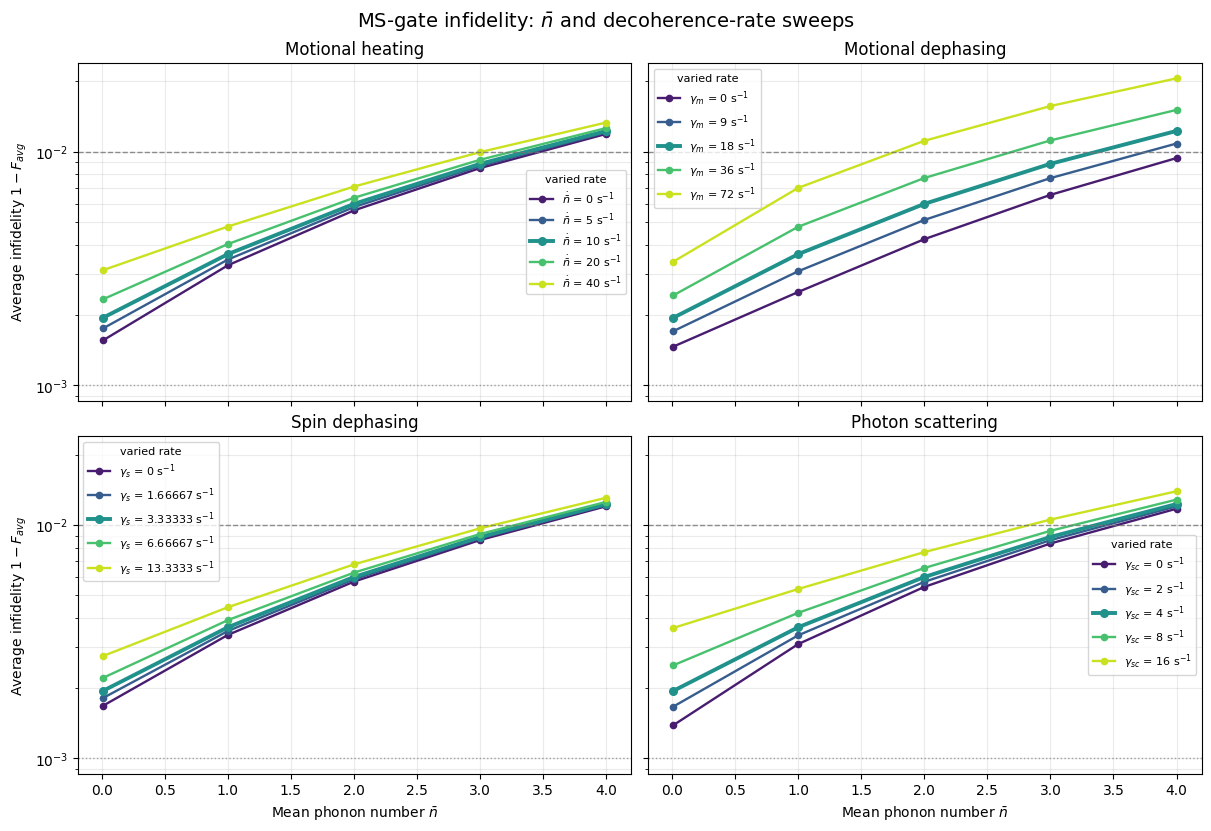

Saved: results/noise_rate_nbar_sweep/infidelity_vs_nbar_by_noise_rate.png


In [5]:
FIGURE_PATH = OUTPUT_DIR / 'infidelity_vs_nbar_by_noise_rate_with_all_noise_zero.png'

def plot_noise_rate_nbar_sweep(summary_table, all_noise_zero_table=None, output_path=None):
    if summary_table.empty:
        print('Nothing to plot. Run or load the QPT sweep first.')
        return None

    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.2), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()
    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(RATE_MULTIPLIERS)))

    for ax, source in zip(axes, NOISE_SOURCES):
        source_table = summary_table[summary_table['noise_source'] == source]
        for color, multiplier, strength in zip(colors, RATE_MULTIPLIERS, RATE_VALUES[source]):
            curve = source_table[np.isclose(source_table['varied_strength_s^-1'], strength)].sort_values('nbar')
            if curve.empty:
                continue
            is_nominal = np.isclose(multiplier, 1.0)
            ax.semilogy(
                curve['nbar'],
                curve['infidelity'],
                marker='o',
                color=color,
                linewidth=2.8 if is_nominal else 1.7,
                markersize=5.5 if is_nominal else 4.5,
                label=legend_label(source, strength),
            )
        if all_noise_zero_table is not None and not all_noise_zero_table.empty:
            zero_curve = all_noise_zero_table.sort_values('nbar')
            ax.semilogy(
                zero_curve['nbar'],
                zero_curve['infidelity'],
                marker='s',
                color='black',
                linestyle='--',
                linewidth=2.2,
                markersize=4.5,
                label='All four noises off',
                zorder=5,
            )
        ax.axhline(1e-2, color='0.45', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.axhline(1e-3, color='0.55', linestyle=':', linewidth=1.0, alpha=0.8)
        ax.set_title(SOURCE_TITLES[source])
        ax.grid(True, which='both', alpha=0.25)
        ax.legend(fontsize=8, title='varied rate', title_fontsize=8)

    for ax in axes[2:]:
        ax.set_xlabel(r'Mean phonon number $\bar{n}$')
    for ax in axes[::2]:
        ax.set_ylabel(r'Average infidelity $1-F_{avg}$')
    fig.suptitle(r'MS-gate infidelity: $\bar{n}$, rate sweeps, and all-noise-zero reference', fontsize=14)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=220, bbox_inches='tight')
    return fig

figure = plot_noise_rate_nbar_sweep(
    summary,
    all_noise_zero_table=all_noise_zero_summary,
    output_path=FIGURE_PATH if not summary.empty else None,
)
if figure is not None:
    plt.show()
    print('Saved:', FIGURE_PATH)

## 6. Noise sensitivity relative to the nominal-rate curve

同じ $\bar{n}$ における基準レート（1.0x）との Infidelity 差を併記します。正値は、そのレート変化によって Infidelity が基準条件より増えたことを意味します。

In [6]:
if summary.empty:
    sensitivity_summary = pd.DataFrame()
else:
    nominal = (
        summary[np.isclose(summary['multiplier'], 1.0)]
        [['noise_source', 'nbar', 'infidelity']]
        .rename(columns={'infidelity': 'nominal_infidelity'})
    )
    sensitivity_summary = summary.merge(nominal, on=['noise_source', 'nbar'], how='left')
    sensitivity_summary['delta_infidelity_vs_nominal'] = (
        sensitivity_summary['infidelity'] - sensitivity_summary['nominal_infidelity']
    )
    sensitivity_summary.to_csv(OUTPUT_DIR / 'sensitivity_vs_nominal.csv', index=False)

display(sensitivity_summary)

,noise_source,multiplier,varied_strength_s^-1,nbar,F_avg,infidelity,nominal_infidelity,delta_infidelity_vs_nominal
0,motional_dephasing,0.0,0.000000,0.01,0.998536,0.001464,0.001947,-0.000482
1,motional_dephasing,0.0,0.000000,1.00,0.997492,0.002508,0.003644,-0.001136
2,motional_dephasing,0.0,0.000000,2.00,0.995777,0.004223,0.005981,-0.001758
3,motional_dephasing,0.0,0.000000,3.00,0.993463,0.006537,0.008878,-0.002341
4,motional_dephasing,0.0,0.000000,4.00,0.990603,0.009397,0.012281,-0.002884
...,...,...,...,...,...,...,...,...
95,spin_dephasing,4.0,13.333333,0.01,0.997256,0.002744,0.001947,0.000797
96,spin_dephasing,4.0,13.333333,1.00,0.995560,0.004440,0.003644,0.000796
97,spin_dephasing,4.0,13.333333,2.00,0.993226,0.006774,0.005981,0.000793
98,spin_dephasing,4.0,13.333333,3.00,0.990332,0.009668,0.008878,0.000790


## Usage notes

1. まず `EXECUTE_QPT=False` で `SCENARIOS` を確認します。
2. 設定が正しければ `EXECUTE_QPT=True` に変え、ノート全体を実行します。
3. 中断後は `RESUME=True` のまま再実行すると、完了済み条件をスキップします。
4. `NBAR_VALUES`、`RATE_MULTIPLIERS`、または `BASE_PARAMETERS` を変える場合は、新しい `OUTPUT_DIR` を使うのが安全です。
5. 追加参照は `all_noise_zero_summary.csv`、基準条件との比較は `all_noise_zero_vs_nominal.csv` に保存されます。
6. 主な図は `infidelity_vs_nbar_by_noise_rate_with_all_noise_zero.png` です。

## 7. Noise-free diagnostic suite

黒破線（4ノイズをすべてゼロ）に残る誤差を、高次Lamb–Dicke項、Fock状態依存性、XX角ずれ、位相空間closure、数値収束性の5つの観点から切り分けます。計算量が大きく異なるため、以下のフラグを1つずつ `True` にして実行してください。

In [10]:
import noise_free_diagnostics as nfd
nfd = importlib.reload(nfd)

DIAGNOSTIC_OUTPUT_DIR = OUTPUT_DIR / 'noise_free_diagnostics'
ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
if (
    'all_noise_zero_summary' not in globals()
    or all_noise_zero_summary.empty
) and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
    print(f'Loaded all-noise-zero reference from {ALL_NOISE_ZERO_SUMMARY_PATH}.')
elif 'all_noise_zero_summary' not in globals():
    all_noise_zero_summary = pd.DataFrame()
    print('All-noise-zero reference is missing; run section 4 first.')

# 重い解析は1つずつ True にする。既存cacheは False でも読み込まれる。
RUN_FULL_VS_LD_QPT = True
RUN_FOCK_RESOLVED = True
RUN_XX_ANGLE_CORRECTION_QPT = True
RUN_NUMERICAL_CONVERGENCE_QPT = True

FOCK_THERMAL_TAIL_TOLERANCE = 1e-5
FOCK_PHONON_BUFFER = 24
CONVERGENCE_NBAR_VALUES = (0.01, 4.0)
CONVERGENCE_PHONON_DIM_FACTORS = (1.0, 1.25, 1.5)
CONVERGENCE_TIME_POINT_FACTORS = (1.0, 1.5, 2.0)

analysis_budget = pd.DataFrame([
    {'analysis': 'full-order vs LD1', 'master_equation_evolutions': 16 * len(NBAR_VALUES), 'other_evolutions': 0},
    {'analysis': 'Fock-resolved', 'master_equation_evolutions': 0, 'other_evolutions': nfd.fock_analysis.required_fock_cutoff(max(NBAR_VALUES), FOCK_THERMAL_TAIL_TOLERANCE) + 1},
    {'analysis': 'XX correction before/after', 'master_equation_evolutions': 2 * 16 * len(NBAR_VALUES), 'other_evolutions': 0},
    {'analysis': 'phase-space closure', 'master_equation_evolutions': 0, 'other_evolutions': 0},
    {'analysis': 'numerical convergence', 'master_equation_evolutions': 16 * len(CONVERGENCE_NBAR_VALUES) * (len(CONVERGENCE_PHONON_DIM_FACTORS) + len(CONVERGENCE_TIME_POINT_FACTORS)), 'other_evolutions': 0},
])
display(analysis_budget)

Loaded all-noise-zero reference from results/noise_rate_nbar_sweep/all_noise_zero_summary.csv.


,analysis,master_equation_evolutions,other_evolutions
0,full-order vs LD1,80,0
1,Fock-resolved,0,52
2,XX correction before/after,160,0
3,phase-space closure,0,0
4,numerical convergence,192,0


### 7.1 Full-order vs first-order Lamb–Dicke

`use_full_order=True` の黒破線と、同じ無ノイズ条件の一次Lamb–Dicke近似（`use_full_order=False`）をfull QPTで比較します。差 $I_{full}-I_{LD1}$ が高次Lamb–Dicke項に対する直接的な指標です。

MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 3.0 Simulation Finished (Dim: 51)
n_bar = 4.0 Simulation Finished (Dim: 67)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 1.733454e-09 (Fidelity = 1.000000)
n_bar = 1.0: Error = 2.392188e-06 (Fidelity = 0.999998)
n_bar = 2.0: Error = 8.139278e-06 (Fidelity = 0.999992)
n_bar = 3.0: Error = 3.573840e-06 (Fidelity = 0.999996)
n_bar = 4.0: Error = 1.825545e-06 (Fidelity = 0.999998)


,nbar,infidelity_full_order,infidelity_lamb_dicke,delta_infidelity_full_minus_ld,higher_order_fraction_of_full
0,0.01,0.000249,1.733454e-09,0.000249,0.999993
1,1.00,0.001302,2.392188e-06,0.001299,0.998163
2,2.00,0.003026,8.139278e-06,0.003018,0.997310
3,3.00,0.005350,3.573840e-06,0.005347,0.999332
4,4.00,0.008221,1.825545e-06,0.008220,0.999778


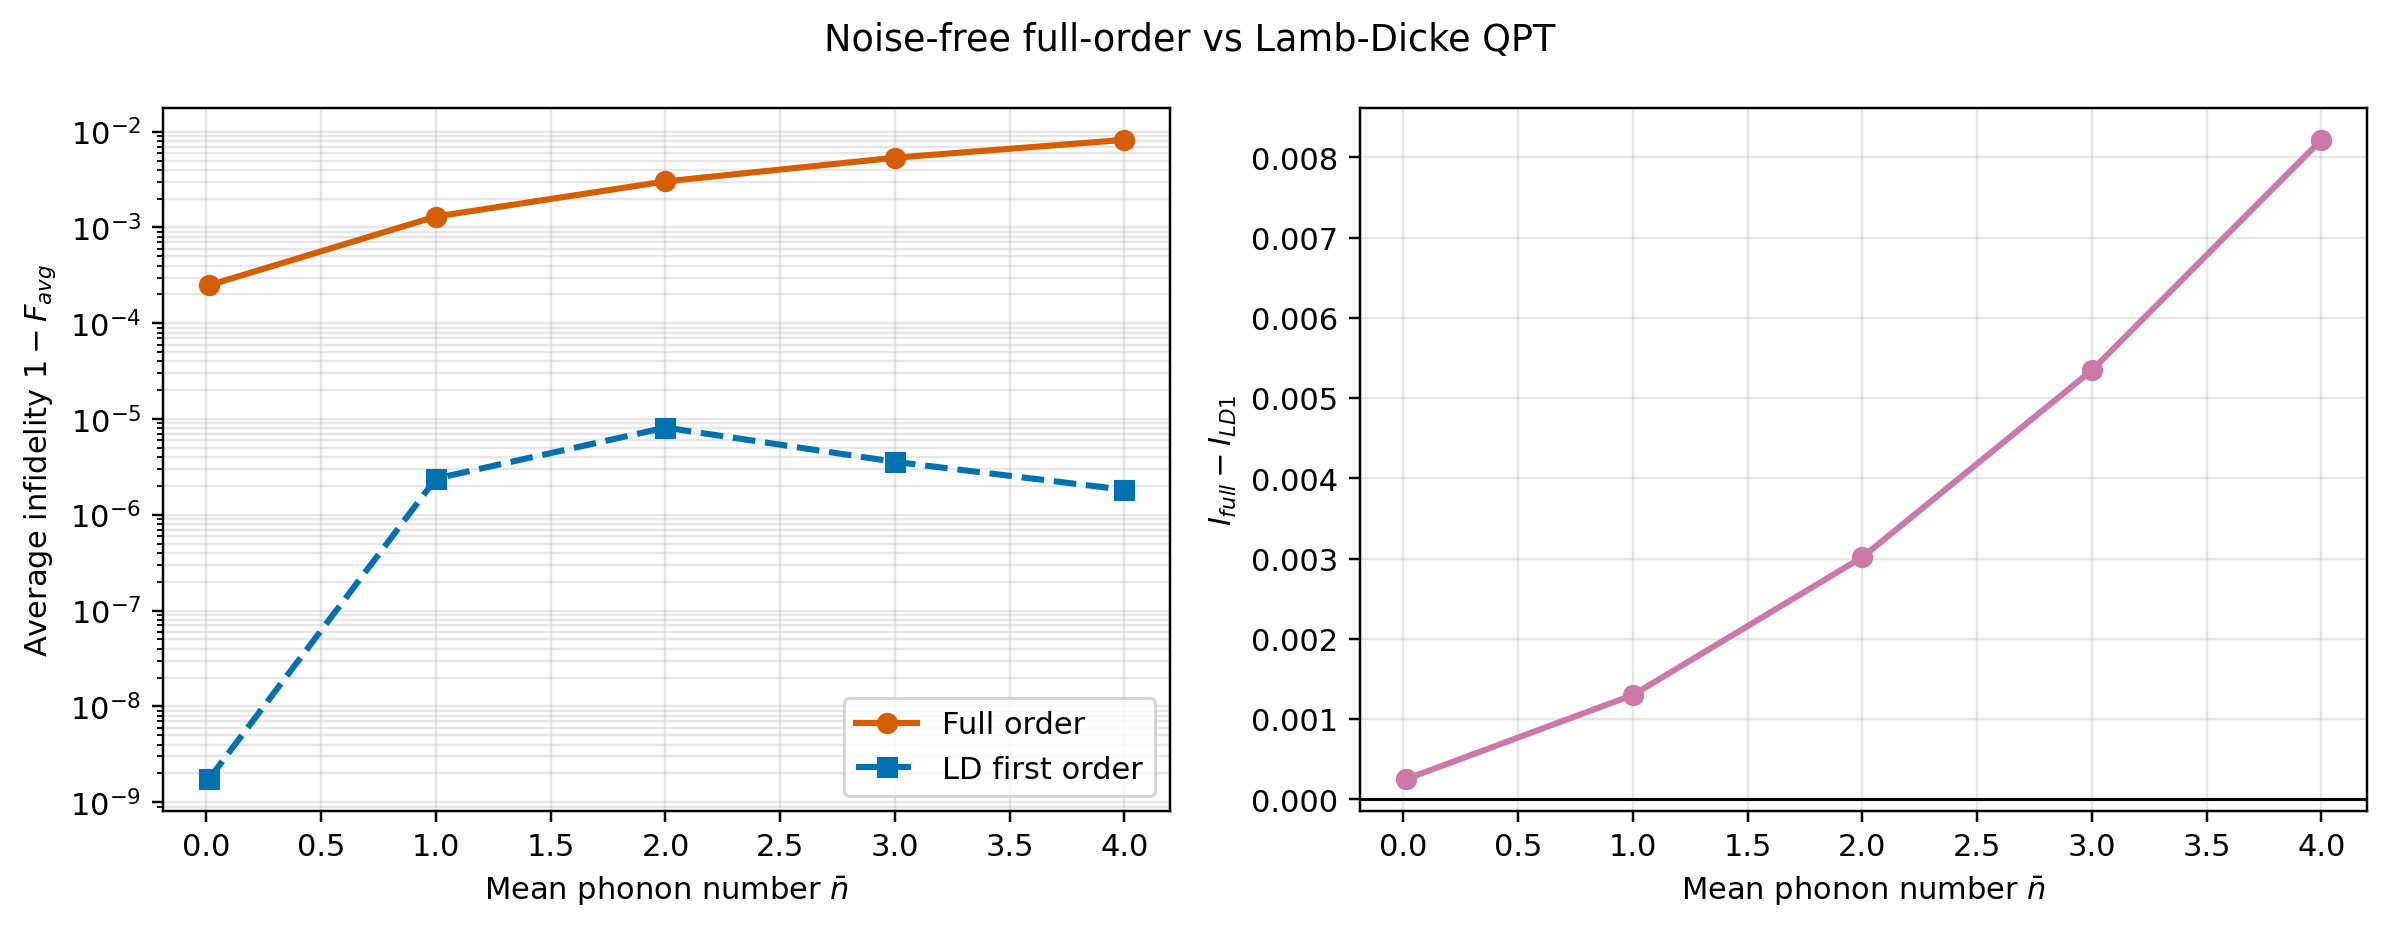

In [11]:
full_vs_ld_result = nfd.run_full_vs_ld_comparison(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'full_vs_lamb_dicke',
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    full_order_summary=all_noise_zero_summary,
    execute=RUN_FULL_VS_LD_QPT,
    resume=RESUME,
)
if full_vs_ld_result['comparison'].empty:
    print('LD1 QPT cache is missing. Set RUN_FULL_VS_LD_QPT=True and rerun this cell.')
else:
    display(full_vs_ld_result['comparison'])
    display(Image(filename=str(full_vs_ld_result['figure_path'])))

### 7.2 Fock-state-resolved analysis

初期Fock状態 $|n\rangle$ ごとに、強制分岐と非強制分岐のcoherence $c_n$ を計算します。$\theta_{XX}(n)=\arg(c_n)/2$ がFock状態ごとのXX角、$1-|c_n|$ が残留spin–motion entanglementの指標です。

Required maximum Fock index: 51


,fock_n,coherence_real,coherence_imag,coherence_abs,theta_xx_rad,theta_error_rad
0,0,0.027160,0.999513,0.999882,0.771815,0.013583
1,1,0.057894,0.997975,0.999653,0.756425,0.028973
2,2,0.088332,0.995524,0.999435,0.741149,0.044249
3,3,0.118450,0.992183,0.999228,0.725988,0.059410
4,4,0.148221,0.987976,0.999032,0.710941,0.074457
5,5,0.177624,0.982927,0.998847,0.696008,0.089390
6,6,0.206635,0.977060,0.998672,0.681190,0.104208
7,7,0.235235,0.970402,0.998506,0.666487,0.118911
8,8,0.263404,0.962976,0.998351,0.651898,0.133500
9,9,0.291124,0.954809,0.998205,0.637424,0.147974


,thermal_n_bar,retained_thermal_mass,thermal_tail_mass,effective_theta_xx_rad,predicted_h_XX_rad_per_gate,theta_xx_linear_mean_rad,theta_xx_variance_rad2,theta_xx_std_rad,mean_forced_null_coherence_abs,gamma_XX_phase_dispersion_per_gate,gamma_XX_with_residual_motion_per_gate,residual_motion_gamma_per_gate
0,0.01,1.000000,0.000000e+00,0.771661,0.013737,0.771661,0.000002,0.001546,0.999875,0.000002,0.000062,0.000060
1,1.00,1.000000,2.220446e-16,0.756559,0.028839,0.756539,0.000460,0.021443,0.998747,0.000459,0.000627,0.000168
2,2.00,1.000000,6.970350e-10,0.741572,0.043826,0.741493,0.001338,0.036583,0.996804,0.001335,0.001601,0.000266
3,3.00,1.000000,3.185559e-07,0.726868,0.058530,0.726675,0.002596,0.050950,0.994141,0.002585,0.002938,0.000353
4,4.00,0.999991,9.134385e-06,0.712461,0.072938,0.712092,0.004192,0.064742,0.990848,0.004166,0.004597,0.000431


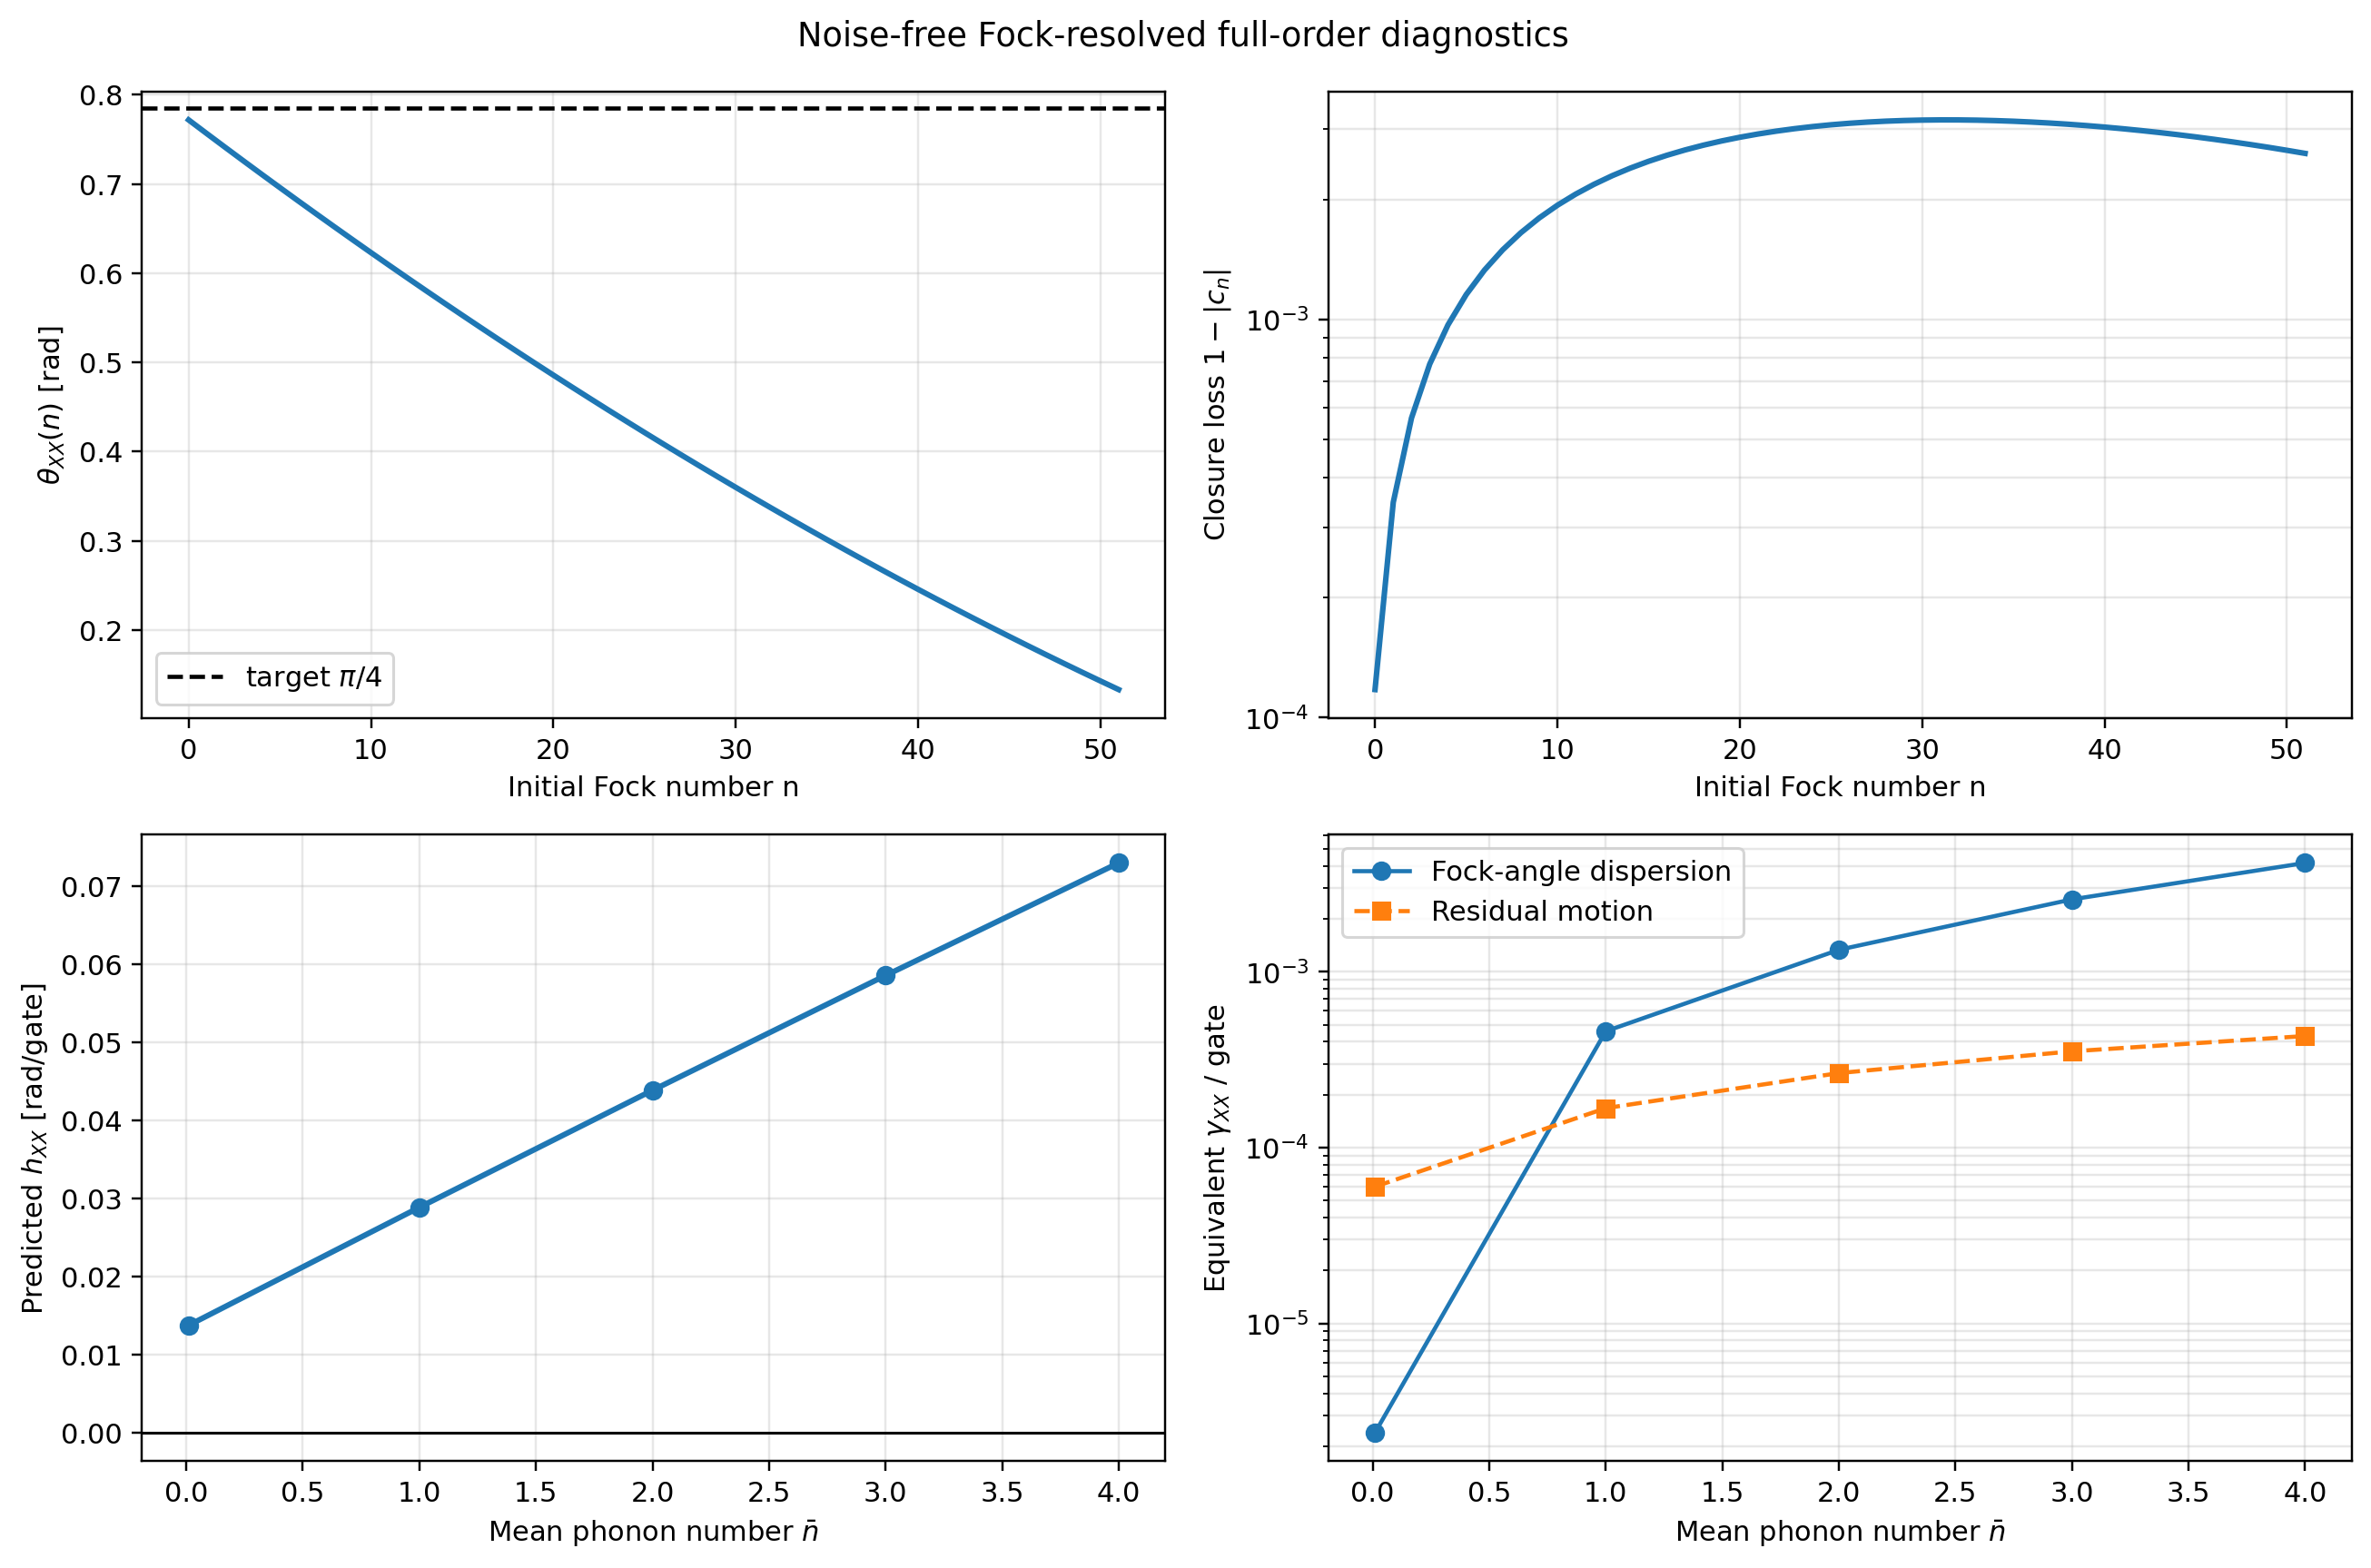

In [12]:
fock_result = nfd.run_fock_resolved_analysis(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'fock_resolved',
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    execute=RUN_FOCK_RESOLVED,
    resume=RESUME,
    thermal_tail_tolerance=FOCK_THERMAL_TAIL_TOLERANCE,
    phonon_buffer=FOCK_PHONON_BUFFER,
)
print(f"Required maximum Fock index: {fock_result['max_fock_n']}")
if fock_result['curve'].empty:
    print('Fock cache is missing. Set RUN_FOCK_RESOLVED=True and rerun this cell.')
else:
    display(fock_result['curve'])
    display(fock_result['thermal_summary'])
    display(Image(filename=str(fock_result['figure_path'])))

### 7.3 Before/after XX-angle correction

無ノイズfull-order QPTから $h_{XX}$ を抽出し、$A_{new}=A\sqrt{(\pi/4)/(\pi/4-h_{XX})}$ の1ステップ補正を行った後に再度full QPTします。補正後にinfidelityが残れば、単純なXX角ずれだけでは説明できない成分です。

MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 1.0 Simulation Finished (Dim: 25)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 1.0 Simulation Finished (Dim: 25)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 2.0 Simulation Finished (Dim: 36)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 2.0 Simulation Finished (Dim: 36)
MS gate simulation progres

,nbar,A_before,A_after,A_factor,h_XX_before_rad_per_gate,h_XX_after_rad_per_gate,theta_XX_before_rad,theta_XX_after_rad,infidelity_before,infidelity_after,infidelity_reduction,gamma_XX_before_per_gate,gamma_XX_after_per_gate
0,0.01,0.125,0.126108,1.008862,0.013737,0.000103,0.771661,0.785296,0.000249,0.000103,0.000146,0.000002,0.000002
1,1.00,0.125,0.127360,1.018881,0.028839,0.000215,0.756559,0.785183,0.001302,0.000697,0.000604,0.000460,0.000495
2,2.00,0.125,0.128641,1.029124,0.043824,0.000320,0.741574,0.785078,0.003026,0.001702,0.001324,0.001336,0.001495
3,3.00,0.125,0.129935,1.039482,0.058529,0.000407,0.726869,0.784991,0.005350,0.003114,0.002237,0.002583,0.003007
4,4.00,0.125,0.131243,1.049943,0.072941,0.000465,0.712457,0.784934,0.008221,0.004938,0.003283,0.004164,0.005040


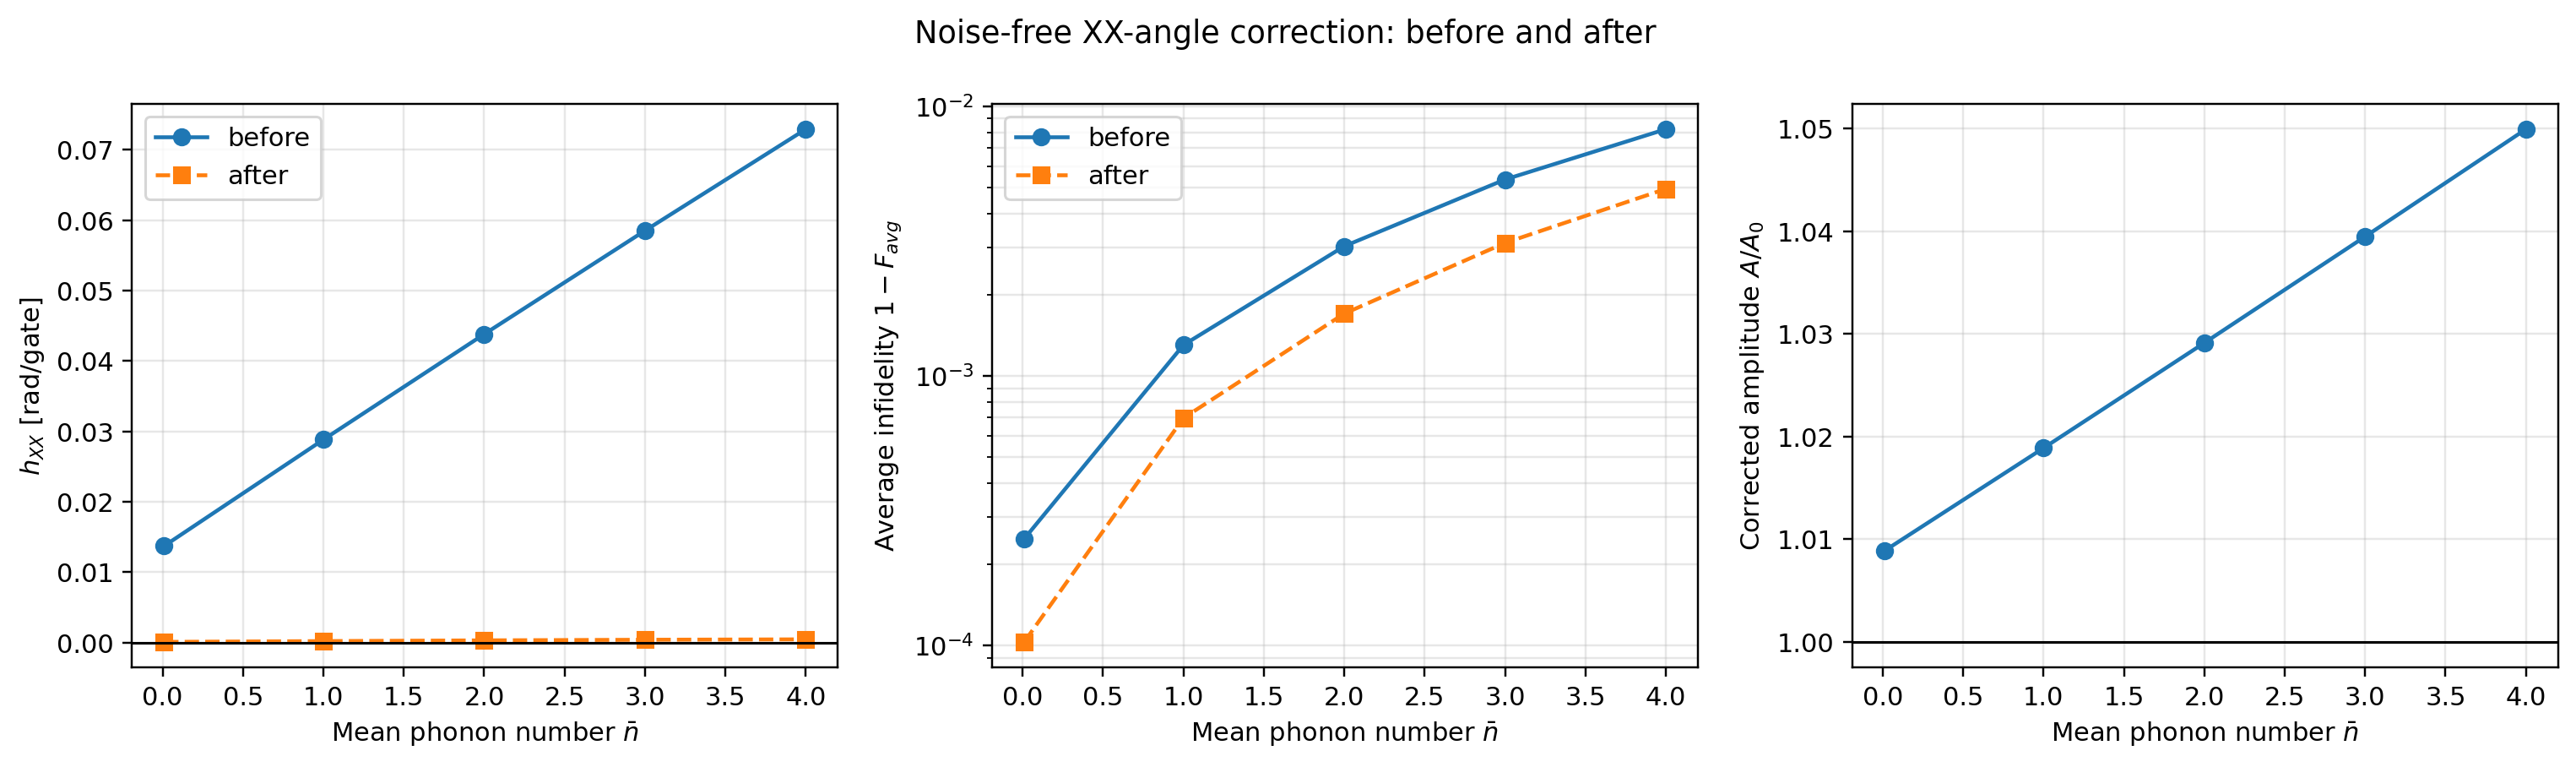

In [13]:
xx_correction_result = nfd.run_xx_angle_correction_comparison(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'xx_angle_correction',
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    execute=RUN_XX_ANGLE_CORRECTION_QPT,
    resume=RESUME,
)
if xx_correction_result['summary'].empty:
    print('XX-correction QPT cache is missing. Set RUN_XX_ANGLE_CORRECTION_QPT=True and rerun this cell.')
    display(xx_correction_result['pending'])
else:
    display(xx_correction_result['summary'])
    display(Image(filename=str(xx_correction_result['figure_path'])))

### 7.4 Phase-space closure

一次Lamb–Dickeモデルの $\alpha(t)$ 軌道と終点 $|\alpha(T)|$、full-orderのFock状態別closure loss、熱平均後の角分散と残留運動成分を並べて表示します。この節は7.2のcacheから作るため、追加のMasterEquation計算はありません。

,thermal_n_bar,retained_thermal_mass,thermal_tail_mass,effective_theta_xx_rad,predicted_h_XX_rad_per_gate,theta_xx_linear_mean_rad,theta_xx_variance_rad2,theta_xx_std_rad,mean_forced_null_coherence_abs,gamma_XX_phase_dispersion_per_gate,gamma_XX_with_residual_motion_per_gate,residual_motion_gamma_per_gate,first_order_displacement_abs,first_order_forced_branch_displacement_abs,first_order_xx_angle_rad,thermal_closure_loss,all_noise_zero_infidelity
0,0.01,1.000000,0.000000e+00,0.771661,0.013737,0.771661,0.000002,0.001546,0.999875,0.000002,0.000062,0.000060,1.000742e-16,2.001483e-16,0.785388,0.000125,0.000249
1,1.00,1.000000,2.220446e-16,0.756559,0.028839,0.756539,0.000460,0.021443,0.998747,0.000459,0.000627,0.000168,1.000742e-16,2.001483e-16,0.785388,0.001253,0.001302
2,2.00,1.000000,6.970350e-10,0.741572,0.043826,0.741493,0.001338,0.036583,0.996804,0.001335,0.001601,0.000266,1.000742e-16,2.001483e-16,0.785388,0.003196,0.003026
3,3.00,1.000000,3.185559e-07,0.726868,0.058530,0.726675,0.002596,0.050950,0.994141,0.002585,0.002938,0.000353,1.000742e-16,2.001483e-16,0.785388,0.005859,0.005350
4,4.00,0.999991,9.134385e-06,0.712461,0.072938,0.712092,0.004192,0.064742,0.990848,0.004166,0.004597,0.000431,1.000742e-16,2.001483e-16,0.785388,0.009152,0.008221


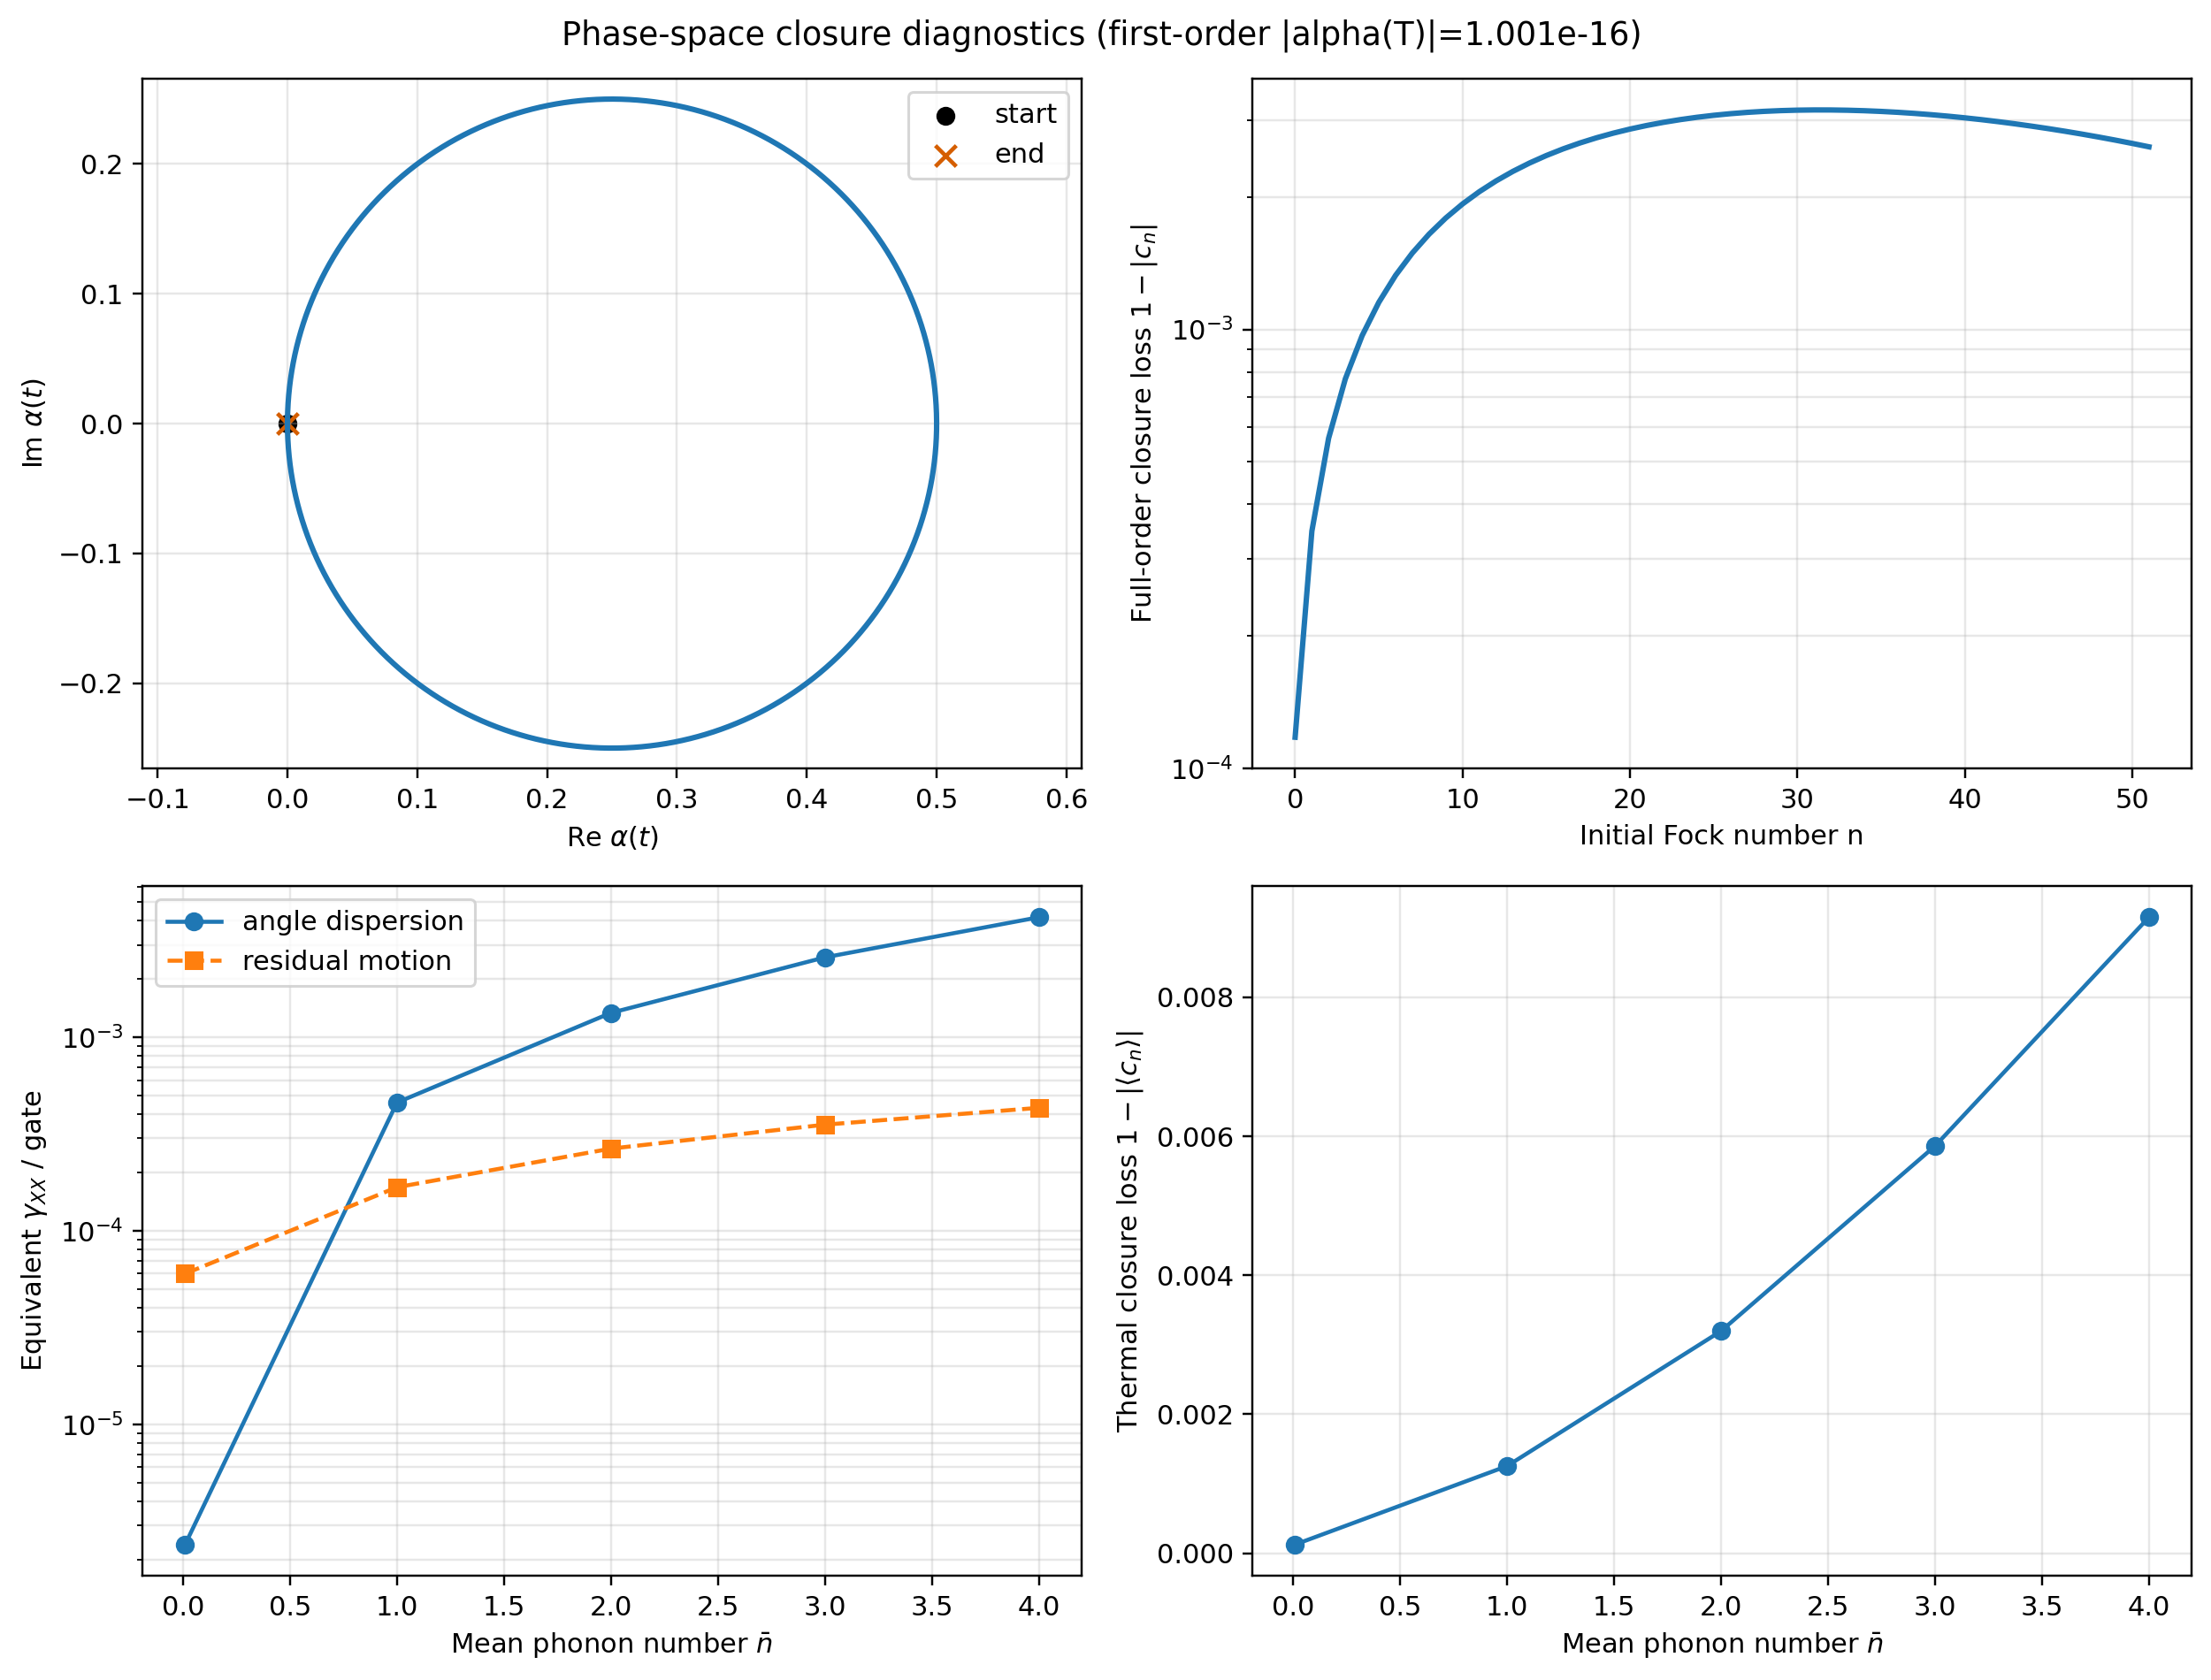

In [14]:
closure_result = nfd.build_phase_space_closure_analysis(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'phase_space_closure',
    base_parameters=BASE_PARAMETERS,
    fock_curve=fock_result['curve'],
    fock_thermal_summary=fock_result['thermal_summary'],
    all_noise_zero_summary=all_noise_zero_summary,
)
if closure_result['summary'].empty:
    print('Run or load the Fock-resolved analysis in section 7.2 first.')
else:
    display(closure_result['summary'])
    display(Image(filename=str(closure_result['figure_path'])))

### 7.5 Numerical convergence

$\bar n=0.01,4$ でphonon cutoffとtime-grid/max-stepを独立に細かくし、最も厳しい設定とのinfidelity差を計算します。`relative_delta_to_reference` が結論に必要な精度より十分小さいことを確認します。

MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 2.487674e-04 (Fidelity = 0.999751)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 25)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 2.487592e-04 (Fidelity = 0.999751)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 30)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 2.487411e-04 (Fidelity = 0.999751)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 30)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 2.487602e-0

,nbar,sweep,phonon_dim,time_points,solver_max_step,auto_phonon_dim,infidelity,reference_infidelity,abs_delta_to_reference,relative_delta_to_reference
0,0.01,phonon_cutoff,20,500,NaN,20,0.000249,0.000248,4.613417e-07,0.001858
1,0.01,phonon_cutoff,25,500,NaN,20,0.000249,0.000248,4.531353e-07,0.001825
2,0.01,phonon_cutoff,30,500,NaN,20,0.000249,0.000248,4.350543e-07,0.001752
3,0.01,time_grid,30,500,0.025183,20,0.000249,0.000248,4.541425e-07,0.001829
4,0.01,time_grid,30,750,0.016778,20,0.000249,0.000248,1.973567e-07,0.000795
5,0.01,time_grid,30,1000,0.012579,20,0.000248,0.000248,0.000000e+00,0.000000
6,4.00,phonon_cutoff,67,500,NaN,67,0.008221,0.008220,1.834358e-06,0.000223
7,4.00,phonon_cutoff,84,500,NaN,67,0.008221,0.008220,1.478659e-06,0.000180
8,4.00,phonon_cutoff,101,500,NaN,67,0.008221,0.008220,1.445057e-06,0.000176
9,4.00,time_grid,101,500,0.025183,67,0.008221,0.008220,1.454621e-06,0.000177


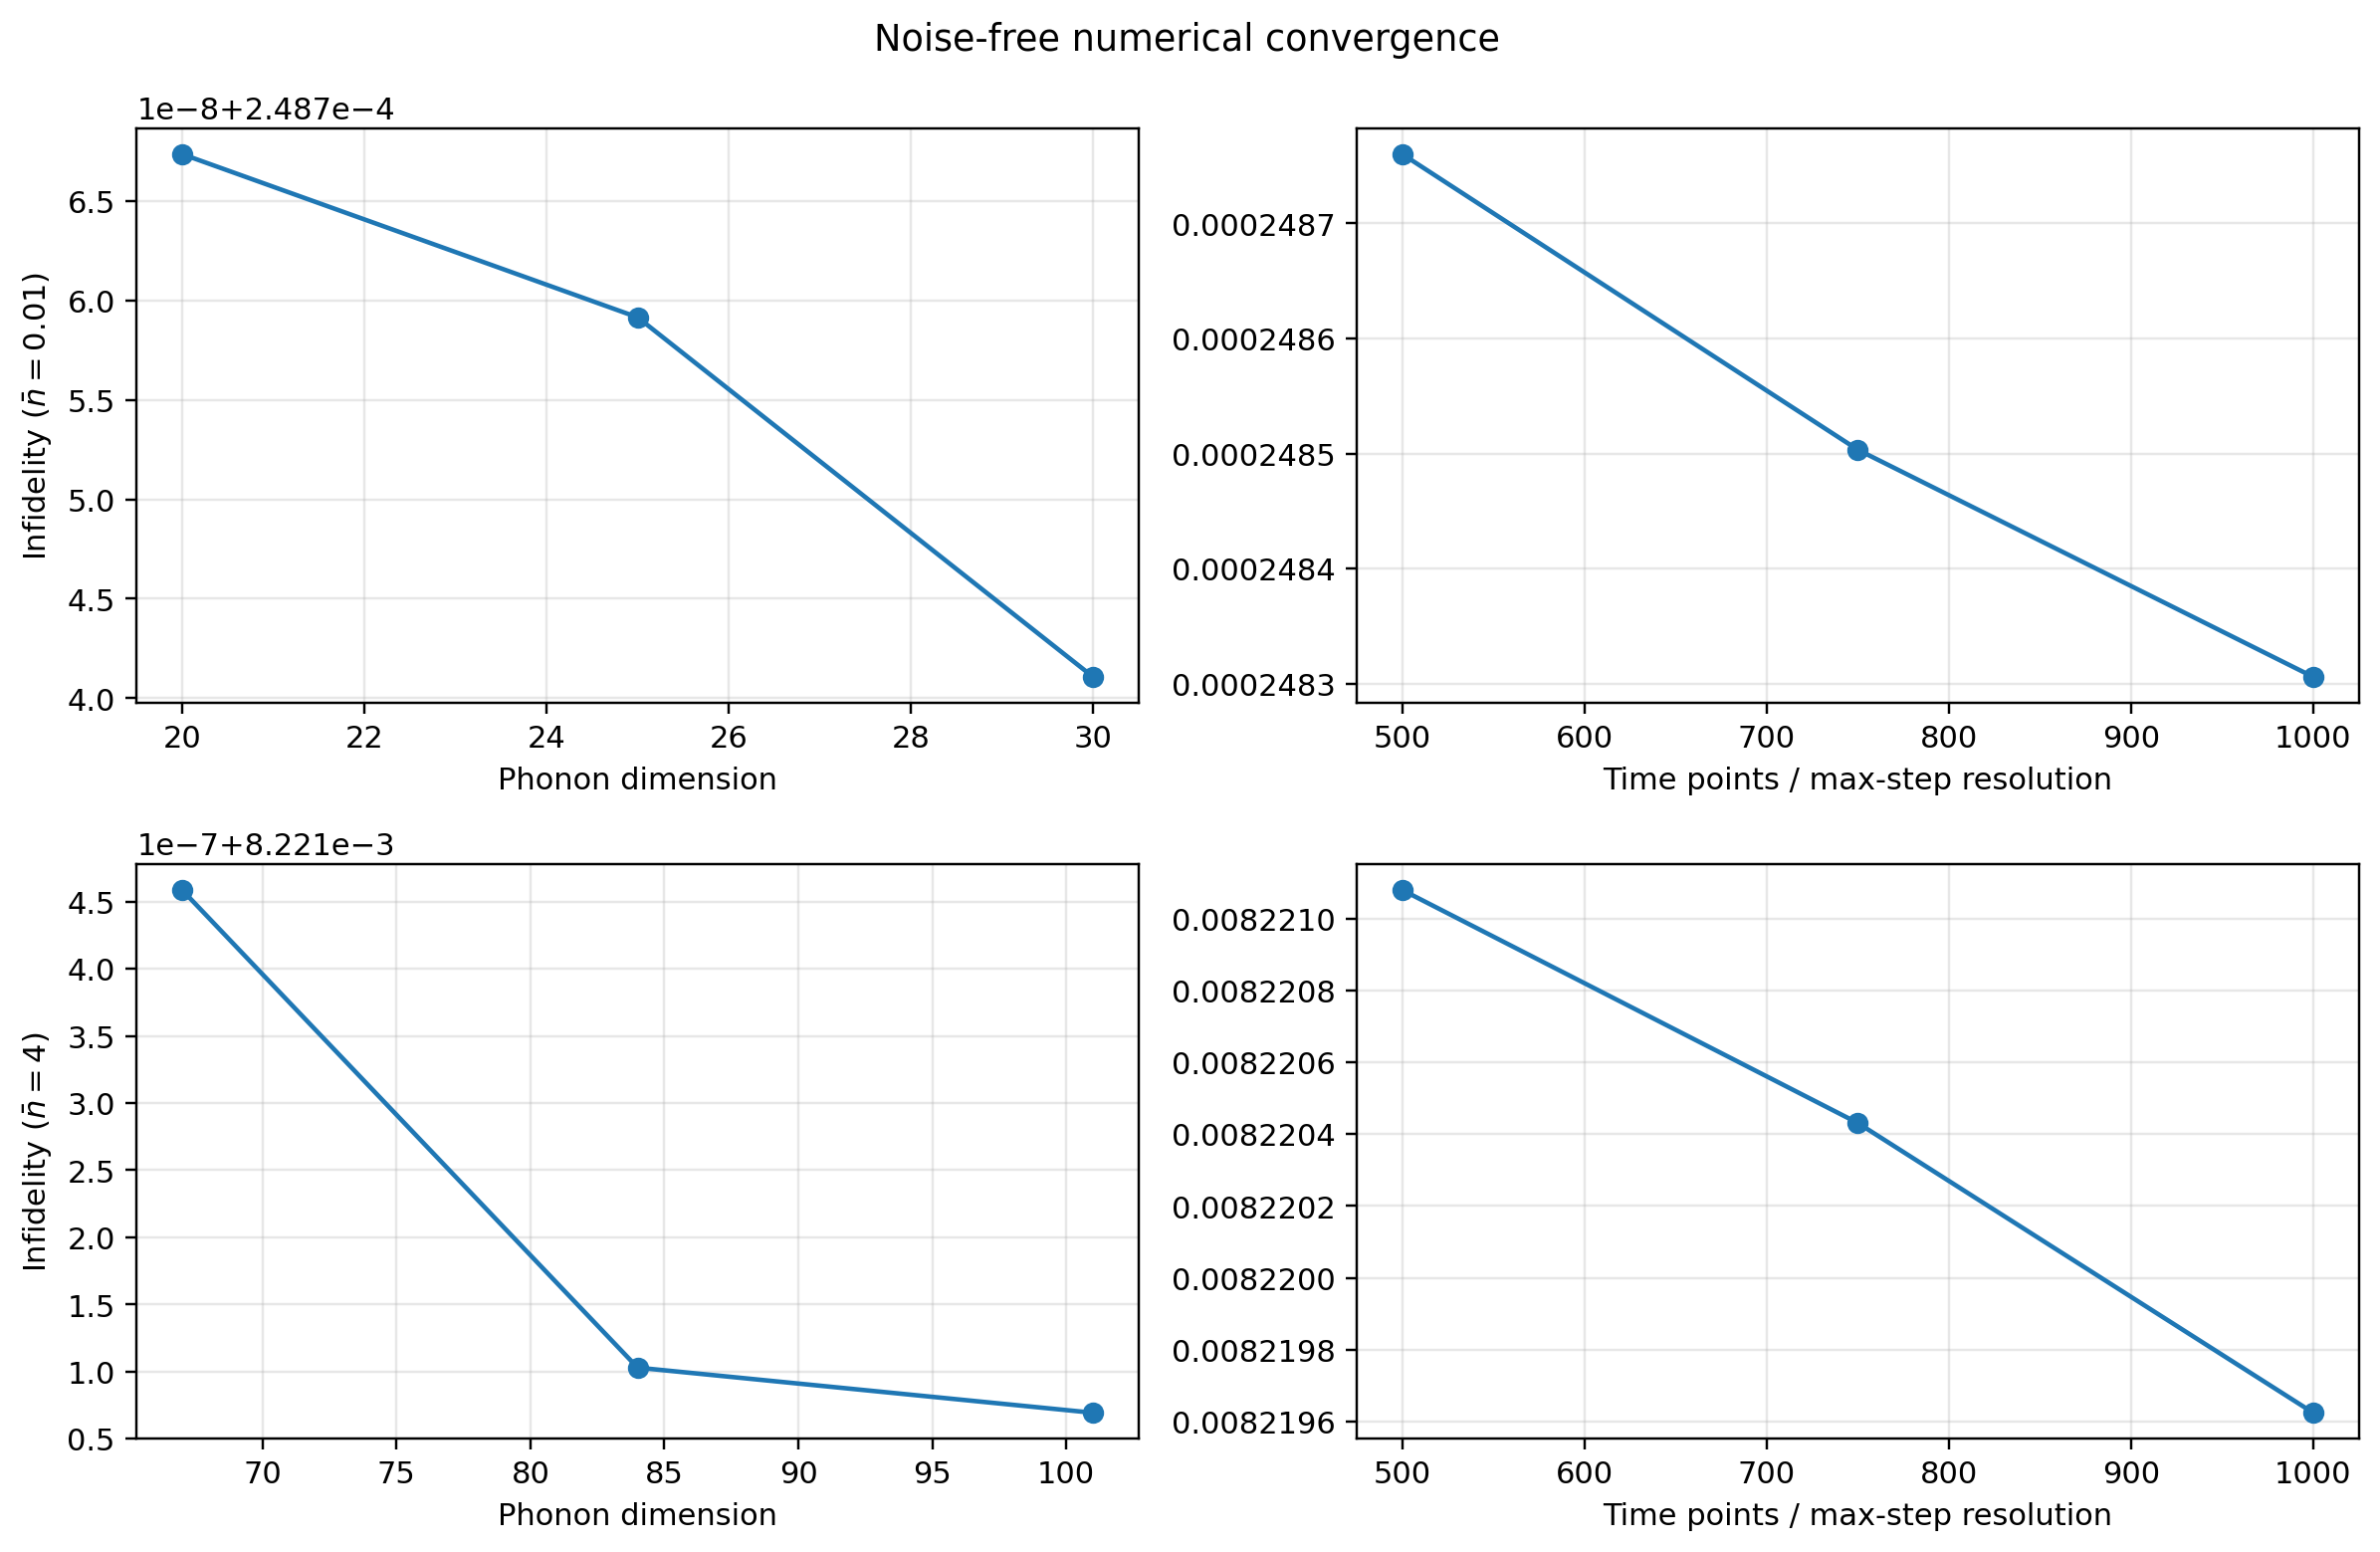

In [15]:
convergence_result = nfd.run_numerical_convergence(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'numerical_convergence',
    base_parameters=BASE_PARAMETERS,
    nbar_values=CONVERGENCE_NBAR_VALUES,
    execute=RUN_NUMERICAL_CONVERGENCE_QPT,
    resume=RESUME,
    phonon_dim_factors=CONVERGENCE_PHONON_DIM_FACTORS,
    time_point_factors=CONVERGENCE_TIME_POINT_FACTORS,
)
if convergence_result['summary'].empty:
    print('Convergence cache is missing. Set RUN_NUMERICAL_CONVERGENCE_QPT=True and rerun this cell.')
    display(convergence_result['requested_points'])
else:
    display(convergence_result['summary'])
    display(Image(filename=str(convergence_result['figure_path'])))

### Interpretation guide

- `delta_infidelity_full_minus_ld > 0`: 高次Lamb–Dicke項が無ノイズinfidelityを増やしている。
- `theta_xx_rad` のFock依存性: 熱分布によるXX角分散の原因。
- XX補正後も残る `infidelity_after`: 単一のcoherent XX角ずれ以外の成分。
- $|\alpha(T)|\simeq0$ でもfull-order closure lossが増える場合: 一次近似では閉じるが、Fock依存の高次項で閉じない。
- 収束誤差が観測した物理効果と同程度なら、物理的な結論より先にcutoff/time-gridを増やす。

## 8. Pairwise dissipative-noise correlations

4ノイズから2つを選ぶ全6ペアに対し、残りの2ノイズをゼロにします。各ペア $(i,j)$ について、$j$ をnominalに固定して $i$ を5レートで掃引し、逆方向も同様に実行します。

同じレートのsingle-noise-only参照を使い、$C_{ij}=I_{ij}-I_i-I_j+I_0$ を計算します。$C_{ij}>0$ は相乗的、$C_{ij}<0$ はsub-additiveな同時作用を表します。これは現在の独立Lindblad項の動力学的非加算性であり、共通bathの統計的相関とは区別します。

In [16]:
import pairwise_noise_correlation as pnc
pnc = importlib.reload(pnc)

PAIRWISE_OUTPUT_DIR = OUTPUT_DIR / 'pairwise_noise_correlation'
PAIRWISE_RATE_MULTIPLIERS = RATE_MULTIPLIERS
PAIRWISE_FIXED_MULTIPLIER = 1.0  # Partner noise is fixed at 1x nominal.
EXECUTE_PAIRWISE_QPT = True  # True: calculate all missing pair/single-only conditions.

# Section 8 can also be started after reopening the notebook.
ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
if (
    'all_noise_zero_summary' not in globals()
    or all_noise_zero_summary.empty
) and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
elif 'all_noise_zero_summary' not in globals():
    all_noise_zero_summary = pd.DataFrame()

pairwise_plan = pnc.build_pairwise_sweep_plan(
    BASE_PARAMETERS,
    PAIRWISE_RATE_MULTIPLIERS,
    fixed_multiplier=PAIRWISE_FIXED_MULTIPLIER,
)
PAIRWISE_EVOLUTIONS_PER_CONDITION = (
    len(NBAR_VALUES) * int(BASE_PARAMETERS.get('laser_noise_samples', 1)) * 16
)
pairwise_budget = pd.DataFrame([{
    'unordered_pairs': len(pairwise_plan['pairs']),
    'requested_cross_sections': len(pairwise_plan['pair_requests']),
    'unique_physical_conditions': len(pairwise_plan['catalog']),
    'reused_all_noise_zero_conditions': 1,
    'new_unique_conditions': len(pairwise_plan['catalog']) - 1,
    'evolutions_per_condition': PAIRWISE_EVOLUTIONS_PER_CONDITION,
    'new_master_equation_evolutions': (len(pairwise_plan['catalog']) - 1) * PAIRWISE_EVOLUTIONS_PER_CONDITION,
}])
display(pairwise_budget)
display(pairwise_plan['pair_requests'][[
    'pair_id', 'varied_source', 'fixed_source',
    'varied_multiplier', 'varied_strength_s^-1', 'fixed_strength_s^-1',
]])

,unordered_pairs,requested_cross_sections,unique_physical_conditions,reused_all_noise_zero_conditions,new_unique_conditions,evolutions_per_condition,new_master_equation_evolutions
0,6,60,59,1,58,80,4640


,pair_id,varied_source,fixed_source,varied_multiplier,varied_strength_s^-1,fixed_strength_s^-1
0,motional_heating__motional_dephasing,motional_heating,motional_dephasing,0.0,0.000000,18.000000
1,motional_heating__motional_dephasing,motional_heating,motional_dephasing,0.5,5.000000,18.000000
2,motional_heating__motional_dephasing,motional_heating,motional_dephasing,1.0,10.000000,18.000000
3,motional_heating__motional_dephasing,motional_heating,motional_dephasing,2.0,20.000000,18.000000
4,motional_heating__motional_dephasing,motional_heating,motional_dephasing,4.0,40.000000,18.000000
5,motional_heating__motional_dephasing,motional_dephasing,motional_heating,0.0,0.000000,10.000000
6,motional_heating__motional_dephasing,motional_dephasing,motional_heating,0.5,9.000000,10.000000
7,motional_heating__motional_dephasing,motional_dephasing,motional_heating,1.0,18.000000,10.000000
8,motional_heating__motional_dephasing,motional_dephasing,motional_heating,2.0,36.000000,10.000000
9,motional_heating__motional_dephasing,motional_dephasing,motional_heating,4.0,72.000000,10.000000


### 8.1 Run/resume the deduplicated QPT conditions

完了した各四レートベクトルは即座にCSV保存されます。`RESUME=True` で再開すると完了済み条件をスキップします。QPTは `BASE_PARAMETERS['parallel_workers']`（現在の `WORKERS`）を使います。

In [17]:
pairwise_result = pnc.run_pairwise_noise_correlation_sweep(
    output_dir=PAIRWISE_OUTPUT_DIR,
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    rate_multipliers=PAIRWISE_RATE_MULTIPLIERS,
    fixed_multiplier=PAIRWISE_FIXED_MULTIPLIER,
    all_noise_zero_summary=all_noise_zero_summary,
    execute=EXECUTE_PAIRWISE_QPT,
    resume=RESUME,
)
print(
    f"Completed rows: {len(pairwise_result['summary'])}; "
    f"pending unique conditions: {pairwise_result['pending_unique_conditions']}; "
    f"pending evolutions: {pairwise_result['pending_master_equation_evolutions']}"
)
if pairwise_result['complete']:
    print('All pairwise and single-noise reference conditions are complete.')
else:
    print('Set EXECUTE_PAIRWISE_QPT=True and rerun this cell to calculate missing conditions.')
    display(pairwise_result['pending_conditions'])

Run pairwise condition 2/59: rates_0ddd426d8d9d7e11
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 3.0 Simulation Finished (Dim: 51)
n_bar = 4.0 Simulation Finished (Dim: 67)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 9.184724e-04 (Fidelity = 0.999082)
n_bar = 1.0: Error = 1.963385e-03 (Fidelity = 0.998037)
n_bar = 2.0: Error = 3.678937e-03 (Fidelity = 0.996321)
n_bar = 3.0: Error = 5.994684e-03 (Fidelity = 0.994005)
n_bar = 4.0: Error = 8.856853e-03 (Fidelity = 0.991143)
Run pairwise condition 3/59: rates_0e752ad71c6095d9
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n

### 8.2 Pairwise cross sections and interaction residuals

1枚目は6ペア×2方向のinfidelity掃引で、すべてのパネルにall-four-noises-offの黒点線を表示します。2枚目は同じ条件の $C_{ij}$ です。

,pair_id,source_i,source_j,varied_source,fixed_source,varied_multiplier,varied_strength_s^-1,fixed_multiplier,fixed_strength_s^-1,condition_id,...,zero_condition_id,nbar,pair_infidelity,varied_only_infidelity,fixed_only_infidelity,zero_infidelity,additive_prediction,interaction_infidelity,pair_noise_penalty,relative_interaction_to_pair_noise
0,motional_dephasing__photon_scattering,motional_dephasing,photon_scattering,motional_dephasing,photon_scattering,0.0,0.000000,1.0,4.0,rates_660d67d330352843,...,rates_7283b228c09abbcb,0.01,0.000808,0.000249,0.000808,0.000249,0.000808,0.000000e+00,0.000560,0.000000
1,motional_dephasing__photon_scattering,motional_dephasing,photon_scattering,motional_dephasing,photon_scattering,0.0,0.000000,1.0,4.0,rates_660d67d330352843,...,rates_7283b228c09abbcb,1.00,0.001861,0.001302,0.001861,0.001302,0.001861,0.000000e+00,0.000559,0.000000
2,motional_dephasing__photon_scattering,motional_dephasing,photon_scattering,motional_dephasing,photon_scattering,0.0,0.000000,1.0,4.0,rates_660d67d330352843,...,rates_7283b228c09abbcb,2.00,0.003584,0.003026,0.003584,0.003026,0.003584,0.000000e+00,0.000558,0.000000
3,motional_dephasing__photon_scattering,motional_dephasing,photon_scattering,motional_dephasing,photon_scattering,0.0,0.000000,1.0,4.0,rates_660d67d330352843,...,rates_7283b228c09abbcb,3.00,0.005906,0.005350,0.005906,0.005350,0.005906,0.000000e+00,0.000556,0.000000
4,motional_dephasing__photon_scattering,motional_dephasing,photon_scattering,motional_dephasing,photon_scattering,0.0,0.000000,1.0,4.0,rates_660d67d330352843,...,rates_7283b228c09abbcb,4.00,0.008775,0.008221,0.008775,0.008221,0.008775,0.000000e+00,0.000554,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,spin_dephasing__photon_scattering,spin_dephasing,photon_scattering,spin_dephasing,photon_scattering,4.0,13.333333,1.0,4.0,rates_25f65c81072ccd16,...,rates_7283b228c09abbcb,0.01,0.001873,0.001314,0.000808,0.000249,0.001874,-8.780091e-07,0.001624,-0.000541
296,spin_dephasing__photon_scattering,spin_dephasing,photon_scattering,spin_dephasing,photon_scattering,4.0,13.333333,1.0,4.0,rates_25f65c81072ccd16,...,rates_7283b228c09abbcb,1.00,0.002924,0.002366,0.001861,0.001302,0.002925,-8.751732e-07,0.001622,-0.000540
297,spin_dephasing__photon_scattering,spin_dephasing,photon_scattering,spin_dephasing,photon_scattering,4.0,13.333333,1.0,4.0,rates_25f65c81072ccd16,...,rates_7283b228c09abbcb,2.00,0.004644,0.004088,0.003584,0.003026,0.004645,-8.733350e-07,0.001619,-0.000540
298,spin_dephasing__photon_scattering,spin_dephasing,photon_scattering,spin_dephasing,photon_scattering,4.0,13.333333,1.0,4.0,rates_25f65c81072ccd16,...,rates_7283b228c09abbcb,3.00,0.006964,0.006409,0.005906,0.005350,0.006965,-8.580182e-07,0.001614,-0.000532


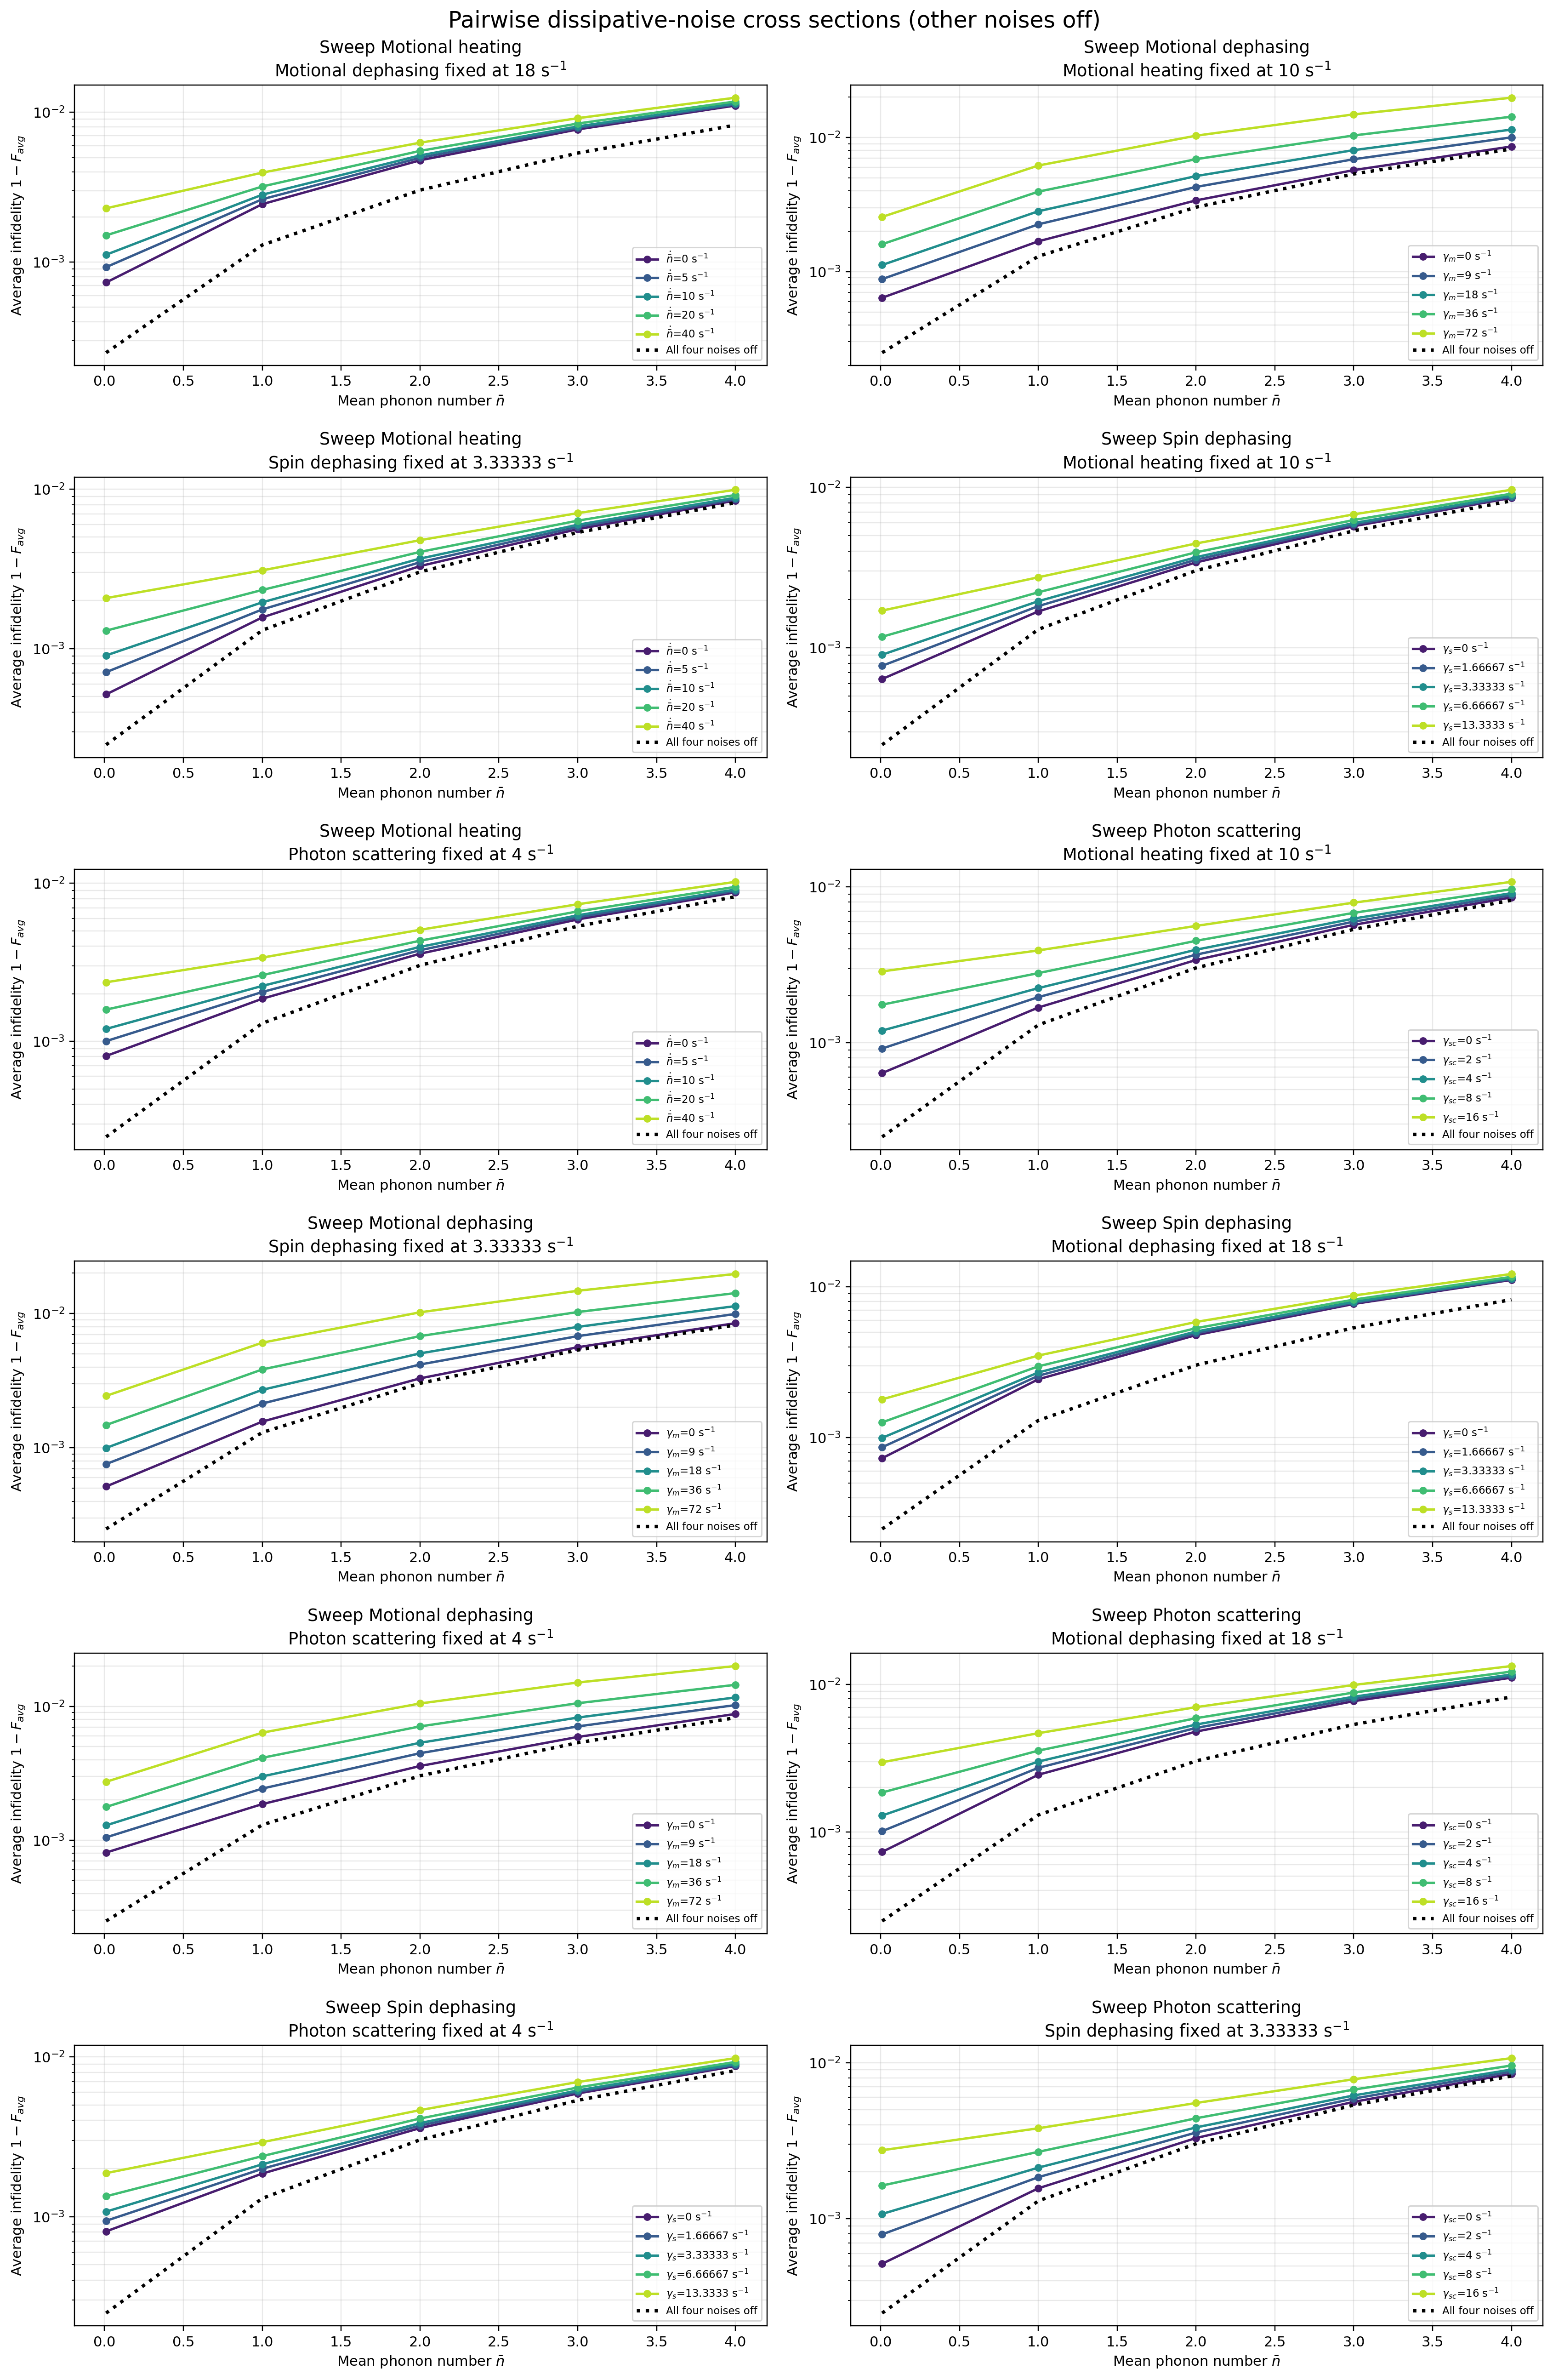

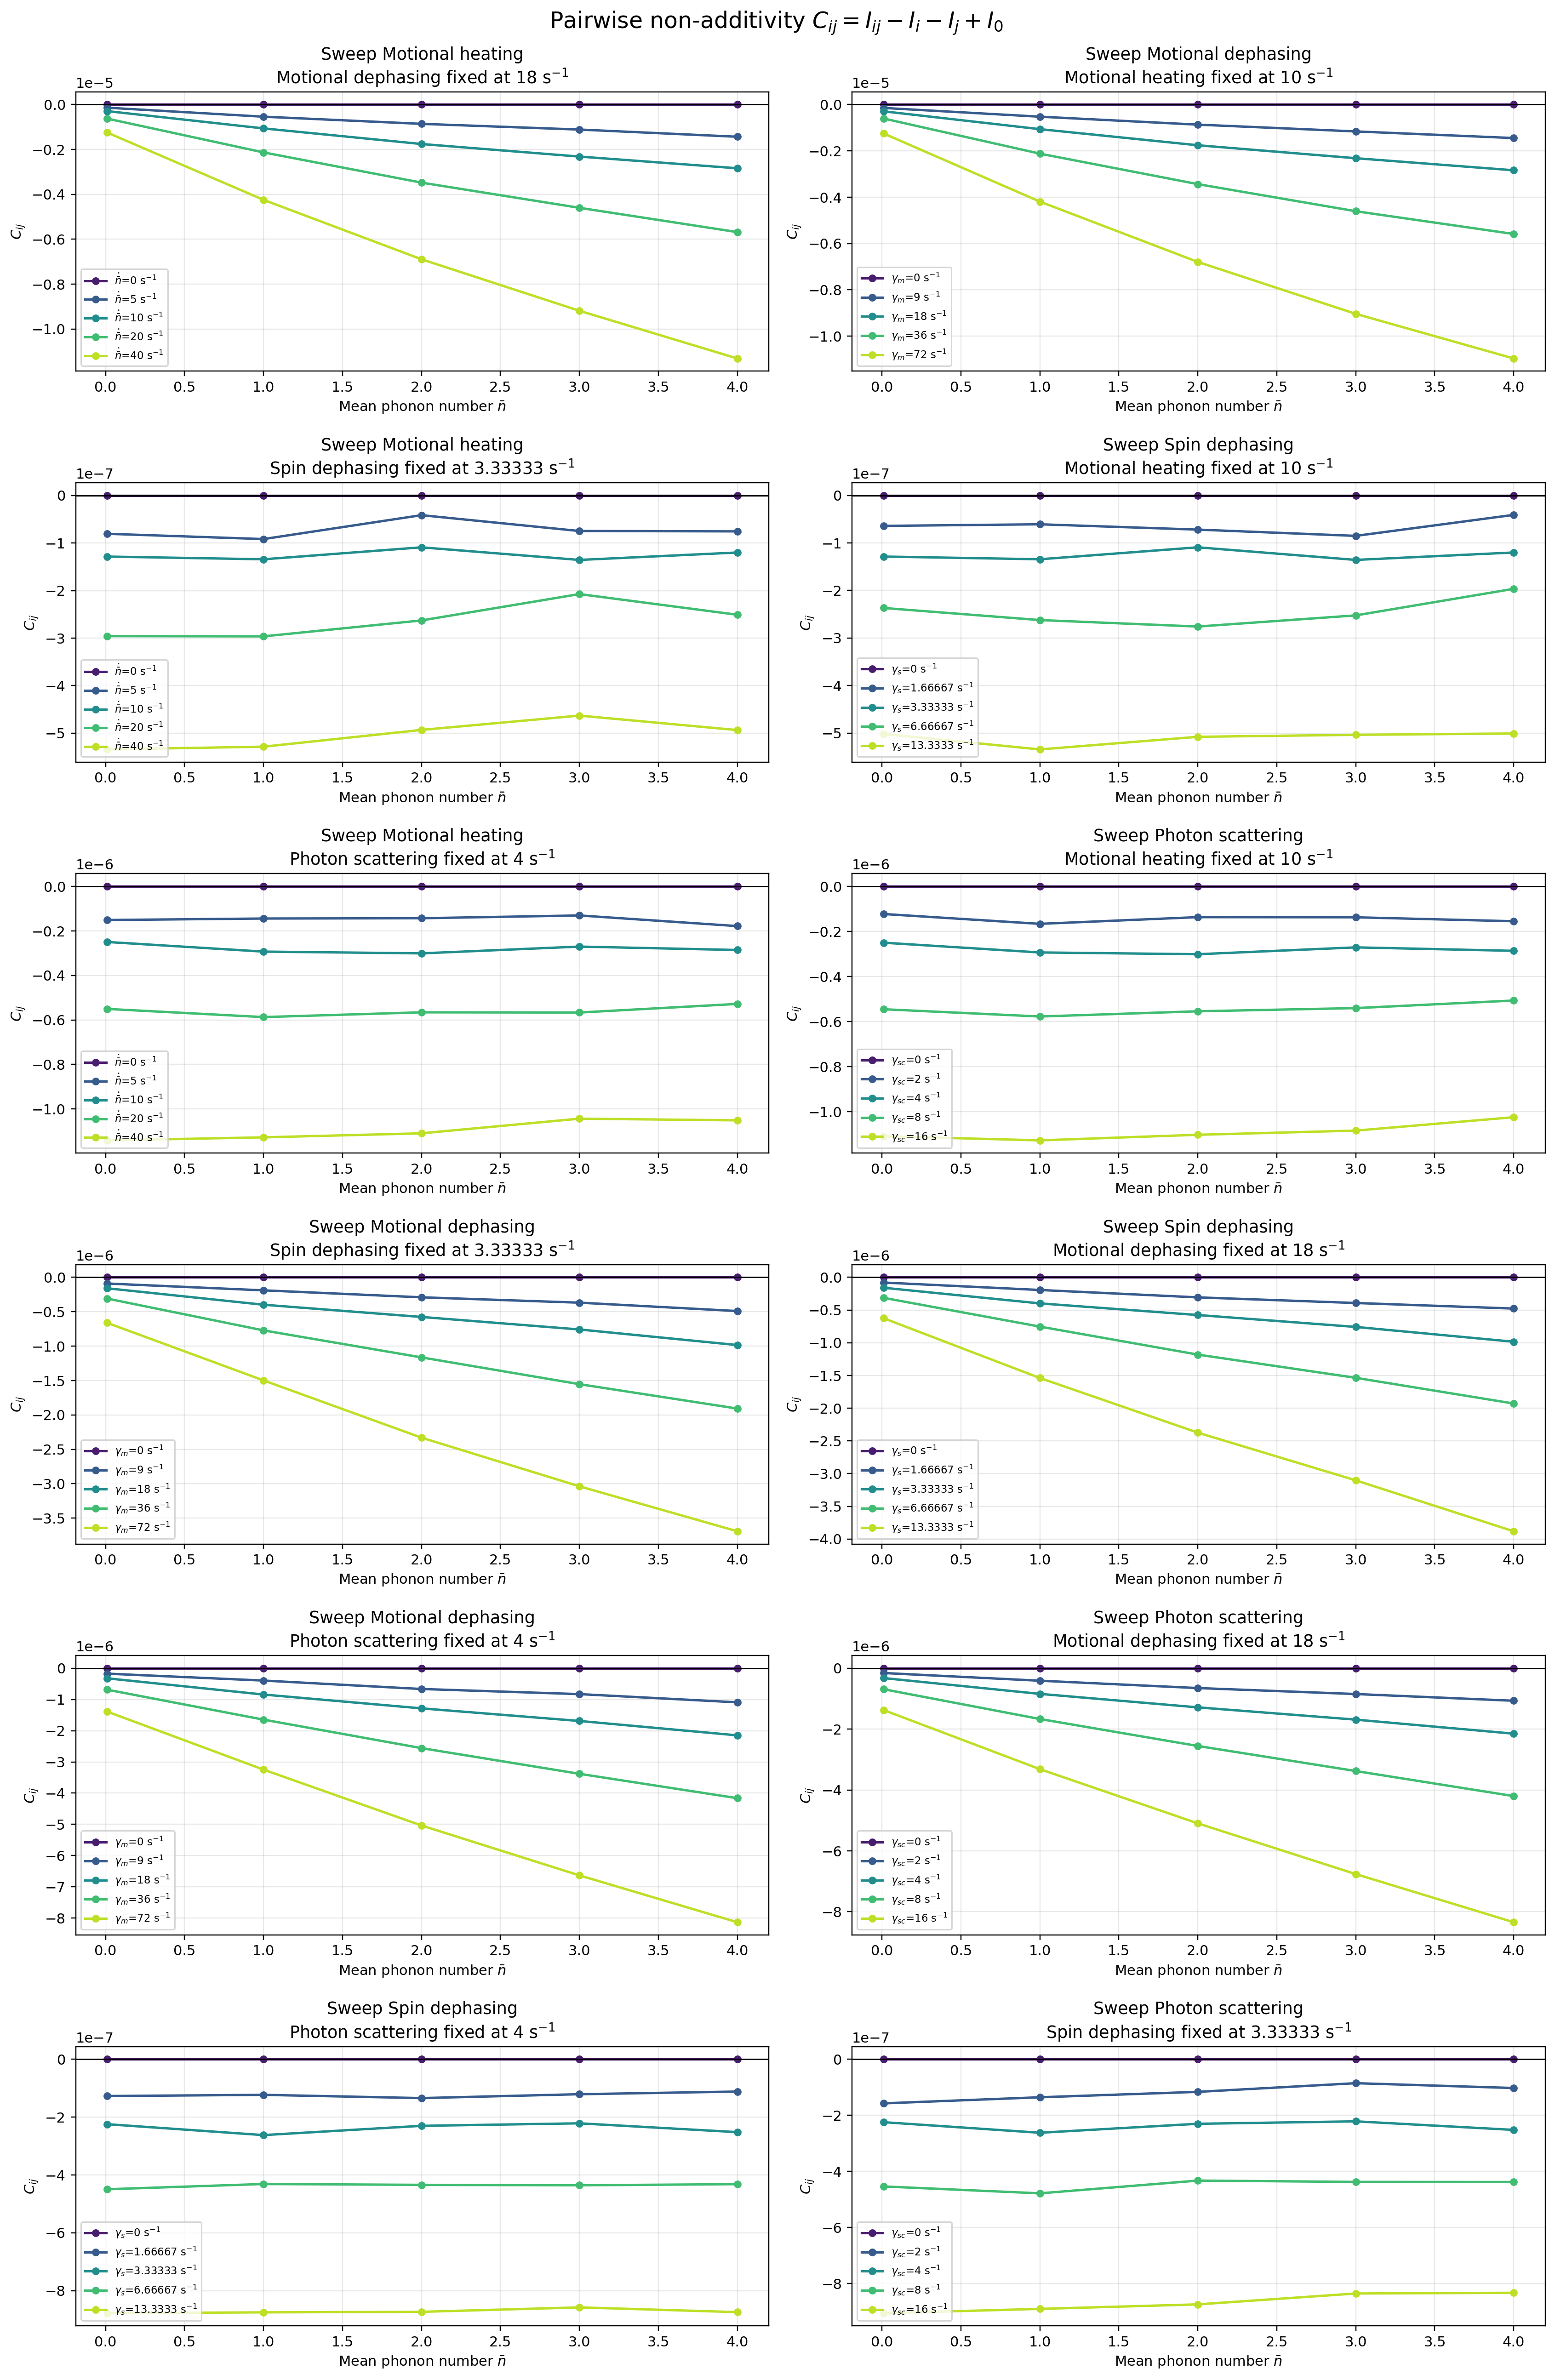

Saved results under: results/noise_rate_nbar_sweep/pairwise_noise_correlation


In [18]:
if pairwise_result['interactions'].empty:
    print('No complete interaction rows are available yet.')
else:
    display(pairwise_result['interactions'])

if pairwise_result['complete']:
    display(Image(filename=str(pairwise_result['figures']['infidelity_figure'])))
    display(Image(filename=str(pairwise_result['figures']['interaction_figure'])))
    print(f"Saved results under: {PAIRWISE_OUTPUT_DIR}")
else:
    print('Figures are generated after all 59 unique physical conditions are complete.')

### 8.3 Interpretation

- `interaction_infidelity` が数値収束誤差より十分大きい場合にのみ、散逸項の非加算的な同時作用と解釈します。
- `relative_interaction_to_pair_noise` は $C_{ij}/(I_{ij}-I_0)$ で、ペアの全ノイズpenaltyに対するinteractionの比率です。
- 掃引側の倍率0ではペア条件が固定側のsingle-noise-onlyと一致するため、$C_{ij}=0$ が内部整合性checkになります。
- この計算は一方を1x nominalに固定した2方向のcross-sectionであり、完全な5×5の二次元gridではありません。

## 9. Heating × Motional dephasing: complete 5×5 rate grid

Motional heatingとmotional dephasingの倍率をそれぞれ $\{0, 0.5, 1, 2, 4\}$ で独立に変化させ、spin dephasingとphoton scatteringは0に固定します。Section 8で完了した条件は物理的に同一な四レートベクトルとして再利用するため、通常は25条件中16条件がcache済み、新規計算は9条件です。

非加算成分は $C_{HM}=I_{HM}-I_H-I_M+I_0$ で定義します。さらに $C_{HM}(m_H,m_M) \approx m_Hm_MC_{HM}(1,1)$ という双線形の弱ノイズモデルからの残差も評価します。

In [19]:
import pairwise_noise_correlation as pnc
pnc = importlib.reload(pnc)

HEATING_DEPHASING_GRID_OUTPUT_DIR = OUTPUT_DIR / 'heating_motional_dephasing_grid'
HEATING_DEPHASING_GRID_MULTIPLIERS = RATE_MULTIPLIERS
EXECUTE_HEATING_DEPHASING_GRID_QPT = True  # True: calculate the missing grid points.

# Reuse the completed physical conditions from Section 8, even after reopening the notebook.
PAIRWISE_SUMMARY_PATH = OUTPUT_DIR / 'pairwise_noise_correlation' / 'pairwise_qpt_summary.csv'
if (
    'pairwise_result' in globals()
    and not pairwise_result['summary'].empty
):
    heating_dephasing_grid_seed = pairwise_result['summary'].copy()
elif PAIRWISE_SUMMARY_PATH.exists():
    heating_dephasing_grid_seed = pd.read_csv(PAIRWISE_SUMMARY_PATH)
else:
    heating_dephasing_grid_seed = pd.DataFrame()

ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
if (
    'all_noise_zero_summary' not in globals()
    or all_noise_zero_summary.empty
) and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
elif 'all_noise_zero_summary' not in globals():
    all_noise_zero_summary = pd.DataFrame()

heating_dephasing_grid_plan = pnc.build_two_noise_grid_plan(
    BASE_PARAMETERS,
    source_x='motional_heating',
    source_y='motional_dephasing',
    rate_multipliers=HEATING_DEPHASING_GRID_MULTIPLIERS,
)

def nbar_values_complete(table, nbar_values):
    if table.empty or 'nbar' not in table.columns:
        return False
    expected = np.sort(np.asarray(nbar_values, dtype=float))
    observed = np.sort(table['nbar'].astype(float).unique())
    return len(observed) == len(expected) and np.allclose(observed, expected, rtol=0, atol=1e-12)

def complete_condition_ids(table, nbar_values):
    if table.empty or not {'condition_id', 'nbar'}.issubset(table.columns):
        return set()
    completed = set()
    for condition_id, rows in table.groupby('condition_id'):
        if nbar_values_complete(rows, nbar_values):
            completed.add(str(condition_id))
    return completed

grid_condition_ids = set(heating_dephasing_grid_plan['catalog']['condition_id'])
cached_grid_ids = complete_condition_ids(heating_dephasing_grid_seed, NBAR_VALUES) & grid_condition_ids
if nbar_values_complete(all_noise_zero_summary, NBAR_VALUES):
    cached_grid_ids.add(heating_dephasing_grid_plan['zero_condition_id'])
GRID_EVOLUTIONS_PER_CONDITION = (
    len(NBAR_VALUES) * int(BASE_PARAMETERS.get('laser_noise_samples', 1)) * 16
)
grid_budget = pd.DataFrame([{
    'total_grid_conditions': len(grid_condition_ids),
    'cached_conditions': len(cached_grid_ids),
    'new_conditions': len(grid_condition_ids - cached_grid_ids),
    'evolutions_per_condition': GRID_EVOLUTIONS_PER_CONDITION,
    'new_master_equation_evolutions': len(grid_condition_ids - cached_grid_ids) * GRID_EVOLUTIONS_PER_CONDITION,
}])
display(grid_budget)
display(heating_dephasing_grid_plan['grid_requests'][[
    'multiplier_x', 'multiplier_y', 'strength_x_s^-1',
    'strength_y_s^-1', 'condition_id',
]])

,total_grid_conditions,cached_conditions,new_conditions,evolutions_per_condition,new_master_equation_evolutions
0,25,16,9,80,720


,multiplier_x,multiplier_y,strength_x_s^-1,strength_y_s^-1,condition_id
0,0.0,0.0,0.0,0.0,rates_7283b228c09abbcb
1,0.5,0.0,5.0,0.0,rates_d40c9e1dbffac54a
2,1.0,0.0,10.0,0.0,rates_a8953962d6e58e19
3,2.0,0.0,20.0,0.0,rates_95304e3098130ea3
4,4.0,0.0,40.0,0.0,rates_0e752ad71c6095d9
5,0.0,0.5,0.0,9.0,rates_70251d48c79bc447
6,0.5,0.5,5.0,9.0,rates_7affb8fbc133d6bd
7,1.0,0.5,10.0,9.0,rates_6d2ebea4f1e4f35a
8,2.0,0.5,20.0,9.0,rates_370adf81f1b648c5
9,4.0,0.5,40.0,9.0,rates_ceb4eecb4eaacfc2


### 9.1 Run/resume the missing grid points

`EXECUTE_HEATING_DEPHASING_GRID_QPT=True`にしてこのセルを実行すると、cacheにない条件だけを計算します。各条件の完了時にCSVを更新し、`RESUME=True`で中断箇所から再開します。CPU並列度は`BASE_PARAMETERS['parallel_workers']`（最初のセルの`WORKERS`）を使います。

In [20]:
heating_dephasing_grid_result = pnc.run_two_noise_rate_grid(
    output_dir=HEATING_DEPHASING_GRID_OUTPUT_DIR,
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    source_x='motional_heating',
    source_y='motional_dephasing',
    rate_multipliers=HEATING_DEPHASING_GRID_MULTIPLIERS,
    reusable_summary=heating_dephasing_grid_seed,
    all_noise_zero_summary=all_noise_zero_summary,
    execute=EXECUTE_HEATING_DEPHASING_GRID_QPT,
    resume=RESUME,
)
print(
    f"Completed/cached unique conditions: {heating_dephasing_grid_result['reused_unique_conditions']}/"
    f"{heating_dephasing_grid_result['total_unique_conditions']}; "
    f"pending conditions: {heating_dephasing_grid_result['pending_unique_conditions']}; "
    f"pending evolutions: {heating_dephasing_grid_result['pending_master_equation_evolutions']}"
)
if heating_dephasing_grid_result['complete']:
    print('The complete Heating x Motional-dephasing 5x5 grid is available.')
else:
    print('Set EXECUTE_HEATING_DEPHASING_GRID_QPT=True and rerun this cell.')
    display(heating_dephasing_grid_result['pending_conditions'])

Run 5x5 grid condition 4/25: rates_17830da3b3822d7d
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 3.0 Simulation Finished (Dim: 51)
n_bar = 4.0 Simulation Finished (Dim: 67)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 2.366700e-03 (Fidelity = 0.997633)
n_bar = 1.0: Error = 5.995030e-03 (Fidelity = 0.994005)
n_bar = 2.0: Error = 1.014020e-02 (Fidelity = 0.989860)
n_bar = 3.0: Error = 1.470770e-02 (Fidelity = 0.985292)
n_bar = 4.0: Error = 1.964711e-02 (Fidelity = 0.980353)
Run 5x5 grid condition 6/25: rates_32d7c04b5236f41d
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n

### 9.2 Heatmaps and bilinear-interaction test

1枚目は全infidelity、2枚目は単独ノイズの和からの差 $C_{HM}$、3枚目は $m_Hm_MC_{HM}(1,1)$ からの残差です。各図はnbarごとの5パネルです。

,nbar,multiplier_x,multiplier_y,grid_infidelity,interaction_infidelity,relative_interaction_to_pair_noise,bilinear_prediction,bilinear_residual,relative_bilinear_residual
0,0.01,0.0,0.0,0.000249,0.000000e+00,0.000000e+00,-0.000000,0.000000e+00,NaN
1,0.01,0.5,0.0,0.000444,-5.421011e-20,-2.779103e-16,-0.000000,-5.421011e-20,NaN
2,0.01,1.0,0.0,0.000639,0.000000e+00,0.000000e+00,-0.000000,0.000000e+00,NaN
3,0.01,2.0,0.0,0.001028,0.000000e+00,0.000000e+00,-0.000000,0.000000e+00,NaN
4,0.01,4.0,0.0,0.001806,2.168404e-19,1.392661e-16,-0.000000,2.168404e-19,NaN
...,...,...,...,...,...,...,...,...,...
120,4.00,0.0,4.0,0.019473,0.000000e+00,0.000000e+00,-0.000000,0.000000e+00,NaN
121,4.00,0.5,4.0,0.019647,-5.499334e-06,-4.813139e-04,-0.000006,1.774244e-07,0.032263
122,4.00,1.0,4.0,0.019821,-1.096302e-05,-9.451381e-04,-0.000011,3.904960e-07,0.035619
123,4.00,2.0,4.0,0.020168,-2.190523e-05,-1.833610e-03,-0.000023,8.018021e-07,0.036603


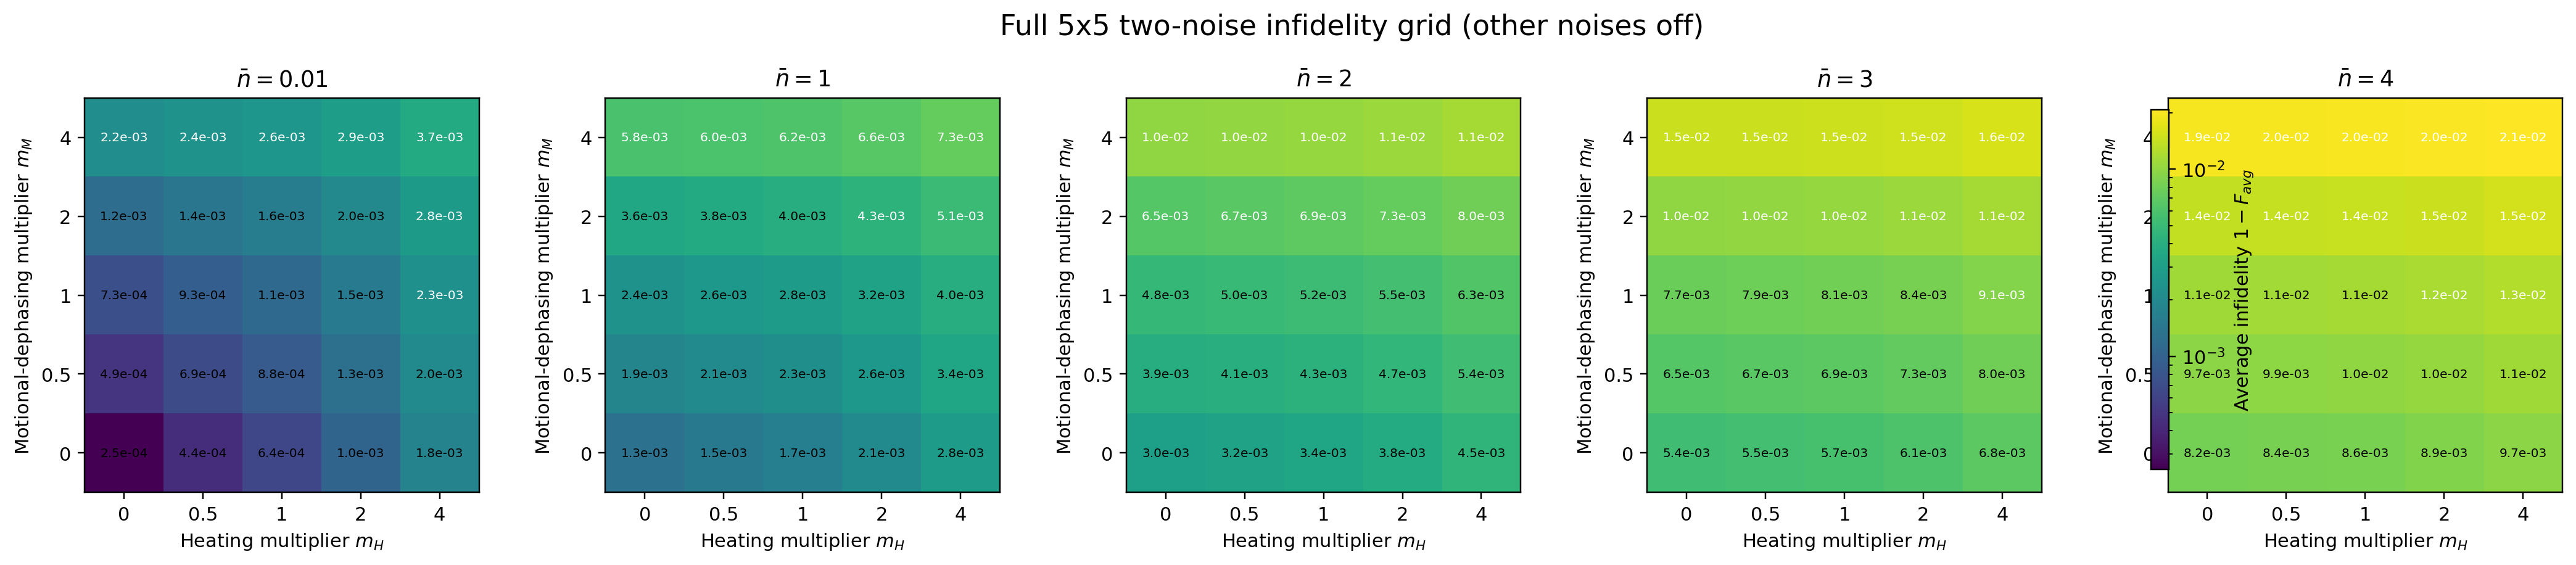

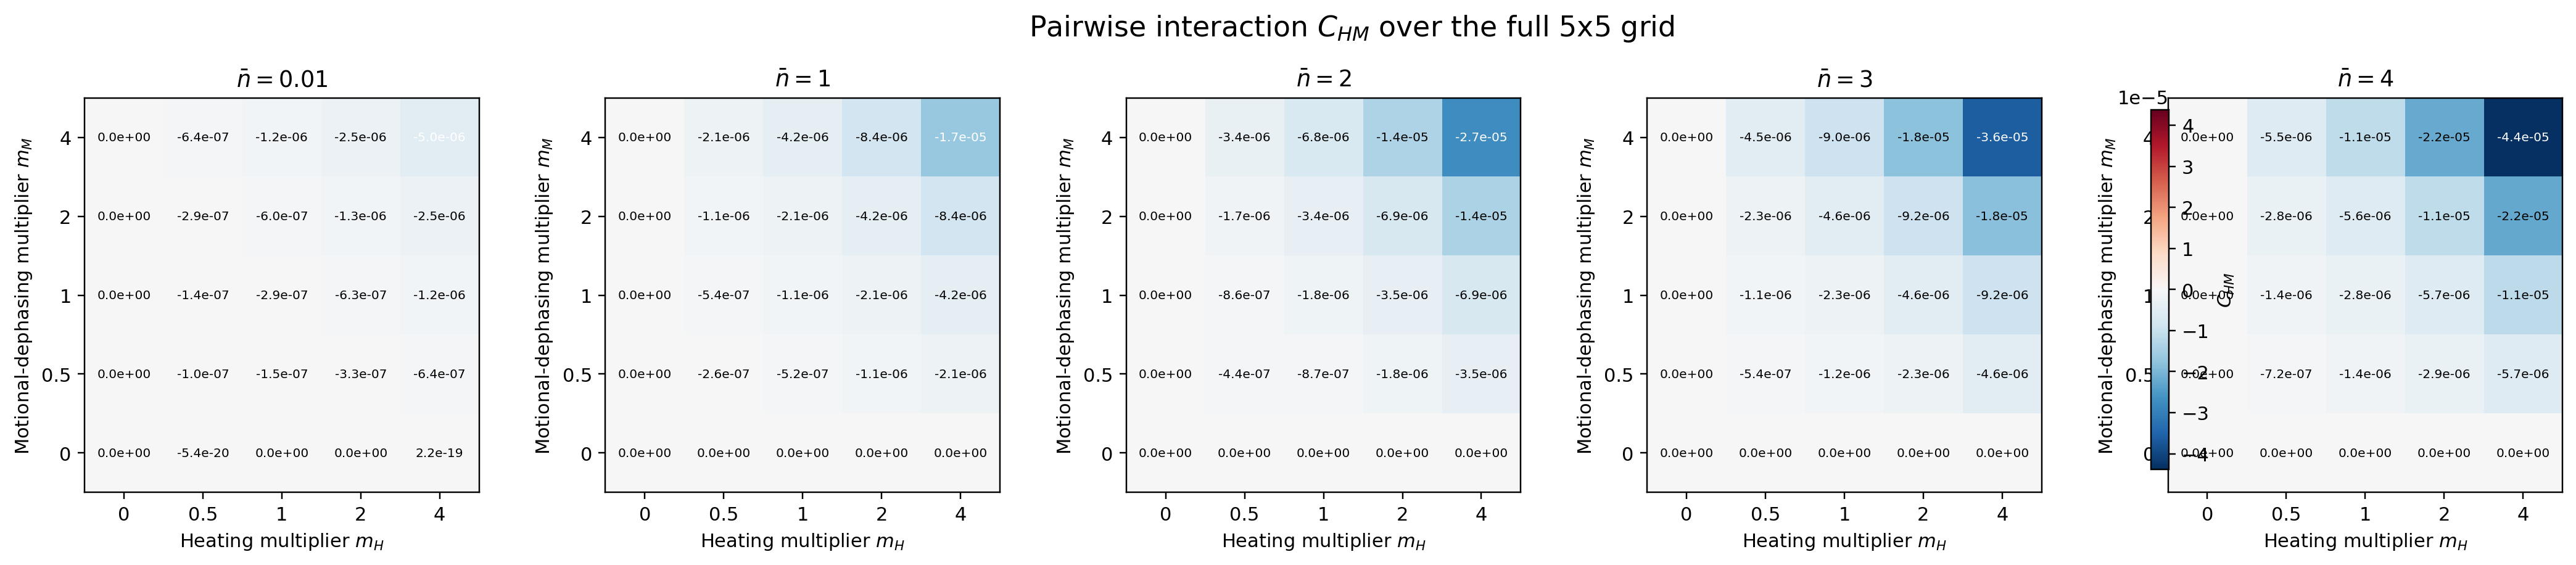

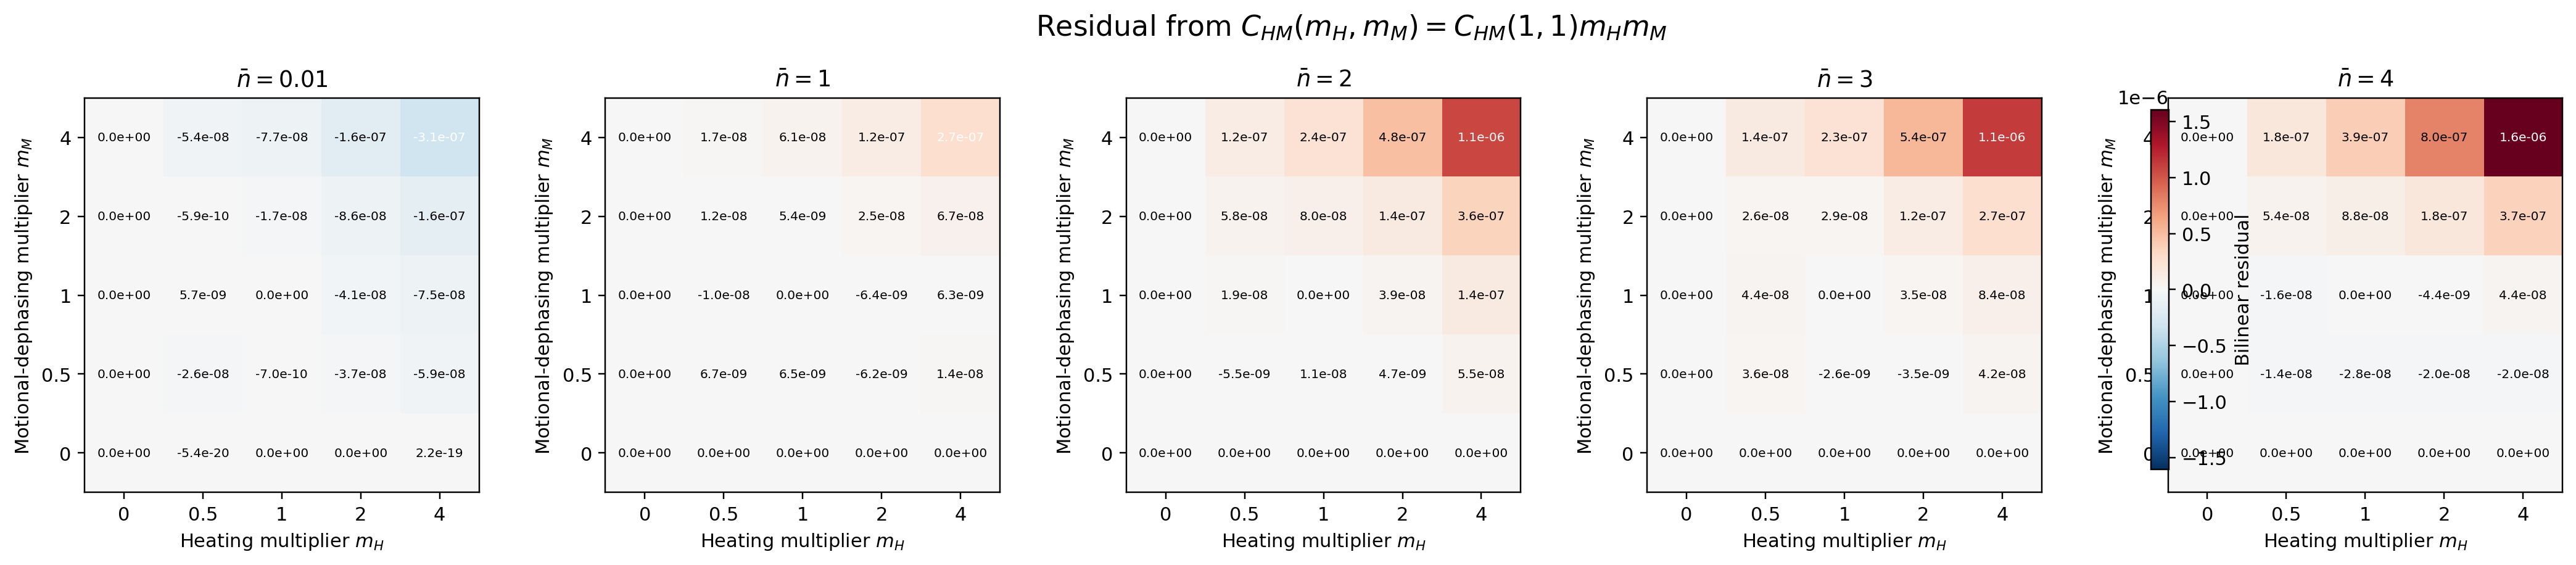

Saved results under: results/noise_rate_nbar_sweep/heating_motional_dephasing_grid


In [21]:
grid_interactions = heating_dephasing_grid_result['grid']
if grid_interactions.empty:
    print('No complete grid coordinates are available yet.')
else:
    display(grid_interactions[[
        'nbar', 'multiplier_x', 'multiplier_y', 'grid_infidelity',
        'interaction_infidelity', 'relative_interaction_to_pair_noise',
        'bilinear_prediction', 'bilinear_residual',
        'relative_bilinear_residual',
    ]])

if heating_dephasing_grid_result['complete']:
    display(Image(filename=str(heating_dephasing_grid_result['figures']['infidelity_figure'])))
    display(Image(filename=str(heating_dephasing_grid_result['figures']['interaction_figure'])))
    display(Image(filename=str(heating_dephasing_grid_result['figures']['bilinear_residual_figure'])))
    print(f"Saved results under: {HEATING_DEPHASING_GRID_OUTPUT_DIR}")
else:
    print('Heatmaps are generated after all 25 physical conditions are complete.')

### 9.3 Interpretation guide

- $C_{HM}>0$ならHeatingとMotional dephasingの同時作用が加算近似よりinfidelityを増やし、$C_{HM}<0$ならsub-additiveです。
- 倍率のどちらかが0の軸上では定義上 $C_{HM}=0$ になるため、数値実装の整合性checkに使えます。
- `bilinear_residual`が数値収束誤差より十分大きく、かつレートとともに系統的に変化する場合、最低次の双線形モデルだけでは説明できない飽和や高次レート依存性を示します。
- $C_{HM}$が0に近い点では`relative_bilinear_residual`が不安定になるため、`bilinear_residual`の絶対値も必ず併記します。

## 10. Reconstruct the nominal four-noise infidelity

既存のall-noise-zero、4つのsingle-noise-only、6つのtwo-noise-only、および実際の4ノイズ同時QPTを使って、nominal rateで4ノイズinfidelityを再構成します。このsectionは保存済みCSVの演算だけで、追加のMasterEquation計算はありません。

$$I_{\mathrm{add}}=I_0+\sum_i(I_i-I_0), \qquad I_{\mathrm{pair}}=I_{\mathrm{add}}+\sum_{i<j}C_{ij},$$

$$C_{ij}=I_{ij}-I_i-I_j+I_0.$$

`pairwise_residual = I_all - I_pair` は、三体・四体の高次成分と数値誤差を含む、pairwise orderで未説明の残差です。

In [11]:
import pairwise_noise_correlation as pnc
pnc = importlib.reload(pnc)

FOUR_NOISE_RECONSTRUCTION_OUTPUT_DIR = OUTPUT_DIR / 'four_noise_reconstruction'
FULL_NOISE_SUMMARY_PATH = OUTPUT_DIR / 'summary.csv'
PAIRWISE_SUMMARY_PATH = OUTPUT_DIR / 'pairwise_noise_correlation' / 'pairwise_qpt_summary.csv'
ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'

# Load all required cached data, also when this section is run after reopening the notebook.
if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    full_four_noise_summary = summary.copy()
elif FULL_NOISE_SUMMARY_PATH.exists():
    full_four_noise_summary = pd.read_csv(FULL_NOISE_SUMMARY_PATH)
else:
    raise FileNotFoundError(f'Missing full-noise summary: {FULL_NOISE_SUMMARY_PATH}')

if (
    'pairwise_result' in globals()
    and not pairwise_result['summary'].empty
):
    four_noise_pairwise_summary = pairwise_result['summary'].copy()
elif PAIRWISE_SUMMARY_PATH.exists():
    four_noise_pairwise_summary = pd.read_csv(PAIRWISE_SUMMARY_PATH)
else:
    raise FileNotFoundError(f'Missing pairwise summary: {PAIRWISE_SUMMARY_PATH}')

if (
    'all_noise_zero_summary' not in globals()
    or all_noise_zero_summary.empty
) and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
elif 'all_noise_zero_summary' not in globals():
    all_noise_zero_summary = pd.DataFrame()

four_noise_pairwise_plan = pnc.build_pairwise_sweep_plan(
    BASE_PARAMETERS,
    RATE_MULTIPLIERS,
    fixed_multiplier=1.0,
)
four_noise_reconstruction_result = pnc.build_four_noise_reconstruction(
    four_noise_pairwise_plan,
    four_noise_pairwise_summary,
    full_four_noise_summary,
    all_noise_zero_summary=all_noise_zero_summary,
    nominal_multiplier=1.0,
)
four_noise_reconstruction_paths = pnc.save_four_noise_reconstruction(
    four_noise_reconstruction_result,
    FOUR_NOISE_RECONSTRUCTION_OUTPUT_DIR,
)
print('Reconstruction used cached CSV data only; no MasterEquation evolution was run.')
print(f'Saved results under: {FOUR_NOISE_RECONSTRUCTION_OUTPUT_DIR}')

Reconstruction used cached CSV data only; no MasterEquation evolution was run.
Saved results under: results/noise_rate_nbar_sweep/four_noise_reconstruction


### 10.1 First-order versus pairwise-corrected prediction

`first_order_residual` と `pairwise_residual` はどちらも `actual - prediction` です。それぞれをactual four-noise penalty $I_{all}-I_0$ で割った値も表示します。

,nbar,zero_infidelity,full_noise_infidelity,first_order_prediction,total_pairwise_correction,pairwise_prediction,first_order_residual,pairwise_residual,first_order_residual_percent,pairwise_residual_percent
0,0.01,0.000249,0.001947,0.001948,-0.000001,0.001947,-0.000001,-5.821450e-08,-0.084490,-0.003429
1,1.00,0.001302,0.003644,0.003647,-0.000003,0.003644,-0.000003,4.823231e-08,-0.125675,0.002059
2,2.00,0.003026,0.005981,0.005985,-0.000004,0.005981,-0.000004,2.163164e-08,-0.143392,0.000732
3,3.00,0.005350,0.008878,0.008883,-0.000005,0.008878,-0.000005,1.839059e-08,-0.152316,0.000521
4,4.00,0.008221,0.012281,0.012287,-0.000007,0.012281,-0.000007,1.080117e-07,-0.160663,0.002661


pair_id,nbar,motional_dephasing__photon_scattering,motional_dephasing__spin_dephasing,motional_heating__motional_dephasing,motional_heating__photon_scattering,motional_heating__spin_dephasing,spin_dephasing__photon_scattering
0,0.01,-3.213619e-07,-1.590968e-07,-2.927865e-07,-2.497621e-07,-1.285473e-07,-2.246419e-07
1,1.00,-8.414133e-07,-3.981194e-07,-1.062954e-06,-2.930460e-07,-1.342646e-07,-2.623139e-07
2,2.00,-1.284373e-06,-5.757830e-07,-1.758089e-06,-3.009174e-07,-1.091123e-07,-2.303254e-07
3,3.00,-1.688062e-06,-7.577356e-07,-2.317338e-06,-2.705240e-07,-1.356099e-07,-2.216473e-07
4,4.00,-2.149100e-06,-9.844009e-07,-2.838379e-06,-2.858273e-07,-1.200234e-07,-2.521083e-07


Max first-order residual / full noise penalty: 0.160663%
Max residual after pairwise correction: 0.00342895%


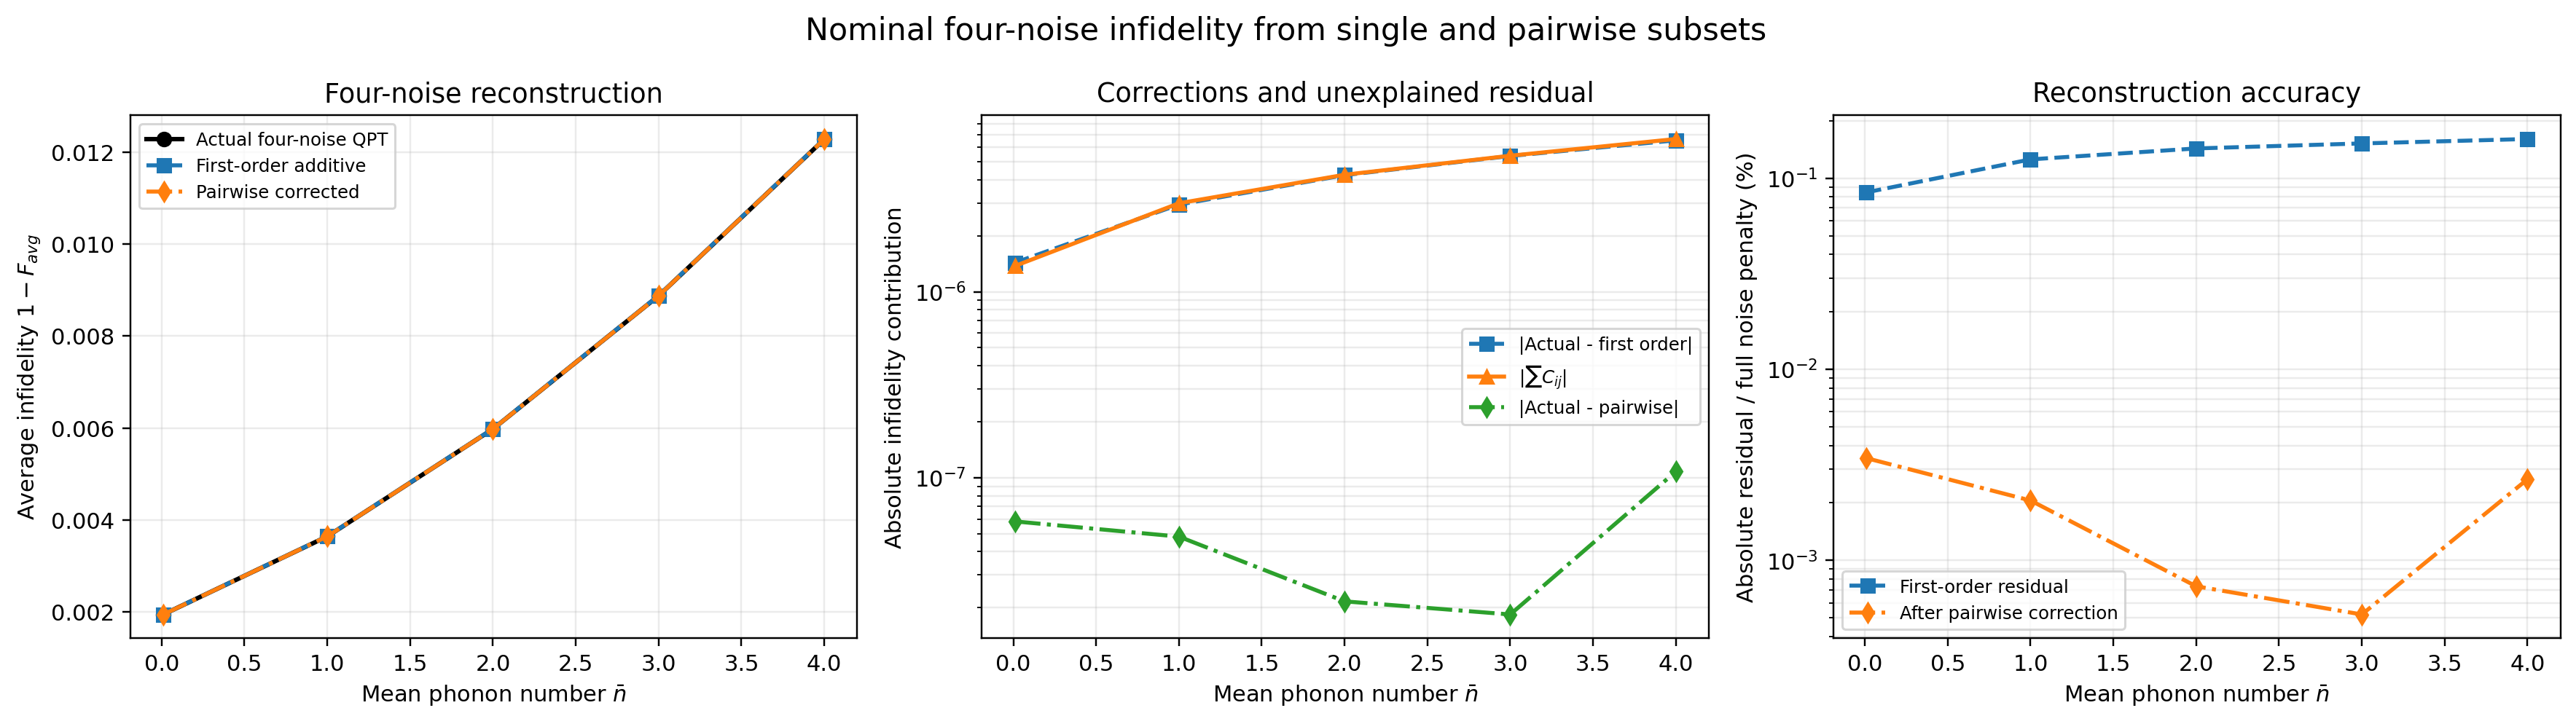

In [12]:
four_noise_reconstruction = four_noise_reconstruction_result['reconstruction'].copy()
four_noise_reconstruction['first_order_residual_percent'] = (
    100.0 * four_noise_reconstruction['first_order_relative_residual_to_noise_penalty']
)
four_noise_reconstruction['pairwise_residual_percent'] = (
    100.0 * four_noise_reconstruction['pairwise_relative_residual_to_noise_penalty']
)
display(four_noise_reconstruction[[
    'nbar', 'zero_infidelity', 'full_noise_infidelity',
    'first_order_prediction', 'total_pairwise_correction',
    'pairwise_prediction', 'first_order_residual', 'pairwise_residual',
    'first_order_residual_percent', 'pairwise_residual_percent',
]])

pairwise_component_table = (
    four_noise_reconstruction_result['pair_components']
    .pivot(index='nbar', columns='pair_id', values='interaction_infidelity')
    .reset_index()
)
display(pairwise_component_table)

max_first_order_percent = 100.0 * np.max(np.abs(
    four_noise_reconstruction['first_order_relative_residual_to_noise_penalty']
))
max_pairwise_percent = 100.0 * np.max(np.abs(
    four_noise_reconstruction['pairwise_relative_residual_to_noise_penalty']
))
print(f'Max first-order residual / full noise penalty: {max_first_order_percent:.6g}%')
print(f'Max residual after pairwise correction: {max_pairwise_percent:.6g}%')
display(Image(filename=str(four_noise_reconstruction_paths['figure'])))

### 10.2 Interpretation guide

- `first_order_residual` が小さければ、4つのsingle-noise penaltyの和だけでactual four-noise penaltyを説明できます。
- `pairwise_residual` が `first_order_residual` より十分小さい場合、一次加算のずれは主に6つのpairwise interactionで説明できます。
- `pairwise_residual` が数値収束誤差より十分大きければ、三体・四体interactionを含むhigher-order contributionの候補です。同程度以下なら、pairwise orderで数値精度内まで再構成できたと解釈します。
- これは物理bathの相関係数ではなく、現在の独立Lindblad散逸モデルにおけるinfidelity responseの包含除展開です。

## 11. Complete 5×5 grids for all six noise pairs

4ノイズからなる全6ペアについて、他の2ノイズを0に固定し、$m_i,m_j\in\{0,0.5,1,2,4\}$の完全5×5 gridを計算します。Section 8と9の同一レートベクトルを再利用するため、現在のキャッシュからの新規計算は45条件、3600 MasterEquation evolutionsです。

各5×5 surfaceは $g_{ij}(\bar n,m_i,m_j)=I_{ij}-I_i-I_j+I_0$ をレートの二次元関数として与え、cross-sectionだけに依存しない任意レート予測の基礎になります。

In [ ]:
import pairwise_noise_correlation as pnc
pnc = importlib.reload(pnc)

ALL_PAIRWISE_GRID_OUTPUT_DIR = OUTPUT_DIR / 'all_pairwise_5x5_grids'
ALL_PAIRWISE_GRID_MULTIPLIERS = RATE_MULTIPLIERS
EXECUTE_ALL_PAIRWISE_GRID_QPT = True  # True: run the 45 missing conditions.

PAIRWISE_SUMMARY_PATH = OUTPUT_DIR / 'pairwise_noise_correlation' / 'pairwise_qpt_summary.csv'
HEATING_DEPHASING_SUMMARY_PATH = (
    OUTPUT_DIR / 'heating_motional_dephasing_grid' / 'two_noise_grid_qpt_summary.csv'
)
ALL_PAIRWISE_AGGREGATE_PATH = (
    ALL_PAIRWISE_GRID_OUTPUT_DIR / 'all_pairwise_grid_qpt_summary.csv'
)
reusable_grid_tables = []
for reusable_path in (
    PAIRWISE_SUMMARY_PATH,
    HEATING_DEPHASING_SUMMARY_PATH,
    ALL_PAIRWISE_AGGREGATE_PATH,
):
    if reusable_path.exists():
        reusable_grid_tables.append(pd.read_csv(reusable_path))
if not reusable_grid_tables:
    raise FileNotFoundError('Run Section 8 first; no pairwise QPT cache was found.')
all_pairwise_grid_seed = (
    pd.concat(reusable_grid_tables, ignore_index=True)
    .drop_duplicates(['condition_id', 'nbar'], keep='last')
)

ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
if (
    'all_noise_zero_summary' not in globals()
    or all_noise_zero_summary.empty
) and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
elif 'all_noise_zero_summary' not in globals():
    all_noise_zero_summary = pd.DataFrame()

all_pairwise_grid_result = pnc.run_all_pairwise_rate_grids(
    output_dir=ALL_PAIRWISE_GRID_OUTPUT_DIR,
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    rate_multipliers=ALL_PAIRWISE_GRID_MULTIPLIERS,
    reusable_summary=all_pairwise_grid_seed,
    all_noise_zero_summary=all_noise_zero_summary,
    execute=EXECUTE_ALL_PAIRWISE_GRID_QPT,
    resume=RESUME,
)
display(all_pairwise_grid_result['budget'])
print(
    f"Pending physical conditions: {all_pairwise_grid_result['pending_conditions']}; "
    f"pending evolutions: {all_pairwise_grid_result['pending_master_equation_evolutions']}"
)
if all_pairwise_grid_result['complete']:
    print('All six complete 5x5 pair grids are available.')
else:
    print('Set EXECUTE_ALL_PAIRWISE_GRID_QPT=True and rerun this cell.')

### 11.1 Grid completion and interaction surfaces

完了後は各ペアのsubdirectoryにinfidelity、$C_{ij}$、bilinear residualのheatmapを保存し、全6ペアのinteractionを1つのCSVに統合します。

In [ ]:
all_pairwise_grid_interactions = all_pairwise_grid_result['interactions']
if all_pairwise_grid_interactions.empty:
    print('No complete interaction coordinates are available yet.')
else:
    positive_rate_points = all_pairwise_grid_interactions[
        (all_pairwise_grid_interactions['multiplier_x'] > 0)
        & (all_pairwise_grid_interactions['multiplier_y'] > 0)
    ].copy()
    pair_surface_summary = (
        positive_rate_points.groupby(['pair_id', 'nbar'])
        .agg(
            min_interaction=('interaction_infidelity', 'min'),
            max_interaction=('interaction_infidelity', 'max'),
            max_abs_interaction=('interaction_infidelity', lambda values: np.max(np.abs(values))),
            max_abs_bilinear_residual=('bilinear_residual', lambda values: np.max(np.abs(values))),
        )
        .reset_index()
    )
    display(pair_surface_summary)
    print(f"Combined interaction CSV: {ALL_PAIRWISE_GRID_OUTPUT_DIR / 'all_pairwise_grid_interactions.csv'}")

## 12. $\kappa_{ij}$ from the Master-equation perturbation expansion

レート倍率 $m_i$ を用いると、Liouvillianは $\mathcal L=\mathcal L_0+\sum_i m_i\mathcal L_i$ と書けます。Master EquationのDyson展開により、infidelityの混合二次係数は

$$\kappa_{ij}(\bar n)=\left.\frac{\partial^2 I}{\partial m_i\partial m_j}\right|_{\boldsymbol m=0}=\lim_{\epsilon\to0}\frac{I_{ij}(\epsilon,\epsilon)-I_i(\epsilon)-I_j(\epsilon)+I_0}{\epsilon^2}.$$

ここでは $\epsilon=(0.5,0.25,0.125)$ でMaster Equationを解き、$C_{ij}(\epsilon,\epsilon)/\epsilon^2$ を $\epsilon\to0$ へ線形外挿します。これはレートgridの1倍点をそのまま係数と見なすのではなく、Master-equation mapのゼロレート混合微分を数値的に直接評価するものです。

Section 11完了後は $\epsilon=0.5$ の11 subset条件を再利用でき、新規計算は20条件、1600 evolutionsです。

In [ ]:
import pairwise_noise_correlation as pnc
pnc = importlib.reload(pnc)

PERTURBATIVE_KAPPA_OUTPUT_DIR = OUTPUT_DIR / 'pairwise_perturbative_kappa'
KAPPA_EPSILON_MULTIPLIERS = (0.5, 0.25, 0.125)
EXECUTE_PERTURBATIVE_KAPPA_QPT = False  # True: run missing small-rate subsets.

# Section 12 can be resumed after reopening the notebook.
ALL_PAIRWISE_GRID_OUTPUT_DIR = OUTPUT_DIR / 'all_pairwise_5x5_grids'
ALL_PAIRWISE_AGGREGATE_PATH = (
    ALL_PAIRWISE_GRID_OUTPUT_DIR / 'all_pairwise_grid_qpt_summary.csv'
)
if 'all_pairwise_grid_seed' not in globals():
    fallback_tables = []
    for fallback_path in (
        OUTPUT_DIR / 'pairwise_noise_correlation' / 'pairwise_qpt_summary.csv',
        OUTPUT_DIR / 'heating_motional_dephasing_grid' / 'two_noise_grid_qpt_summary.csv',
    ):
        if fallback_path.exists():
            fallback_tables.append(pd.read_csv(fallback_path))
    all_pairwise_grid_seed = (
        pd.concat(fallback_tables, ignore_index=True)
        .drop_duplicates(['condition_id', 'nbar'], keep='last')
        if fallback_tables else pd.DataFrame()
    )
ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
if (
    'all_noise_zero_summary' not in globals()
    or all_noise_zero_summary.empty
) and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
elif 'all_noise_zero_summary' not in globals():
    all_noise_zero_summary = pd.DataFrame()

if (
    'all_pairwise_grid_result' in globals()
    and not all_pairwise_grid_result['summary'].empty
):
    perturbative_kappa_seed = all_pairwise_grid_result['summary'].copy()
elif ALL_PAIRWISE_AGGREGATE_PATH.exists():
    perturbative_kappa_seed = pd.read_csv(ALL_PAIRWISE_AGGREGATE_PATH)
else:
    perturbative_kappa_seed = all_pairwise_grid_seed.copy()

perturbative_kappa_result = pnc.run_pairwise_perturbative_kappa(
    output_dir=PERTURBATIVE_KAPPA_OUTPUT_DIR,
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    epsilon_multipliers=KAPPA_EPSILON_MULTIPLIERS,
    reusable_summary=perturbative_kappa_seed,
    all_noise_zero_summary=all_noise_zero_summary,
    execute=EXECUTE_PERTURBATIVE_KAPPA_QPT,
    resume=RESUME,
)
print(
    f"Completed conditions: {perturbative_kappa_result['completed_conditions']}/"
    f"{perturbative_kappa_result['total_conditions']}; "
    f"pending evolutions: {perturbative_kappa_result['pending_master_equation_evolutions']}"
)
if perturbative_kappa_result['complete']:
    print('All zero-rate mixed derivatives are available.')
else:
    print('Complete Section 11, then set EXECUTE_PERTURBATIVE_KAPPA_QPT=True and rerun this cell.')
    display(perturbative_kappa_result['pending_conditions'])

### 12.1 Extrapolated mixed-response coefficients

`kappa_multiplier_zero_rate`はnominal rate倍率に対する係数、`kappa_physical_s2_zero_rate`は物理レート $\gamma_i,\gamma_j$ に対する係数です。`extrapolation_difference`は細かい2点と粗い2点から得た外挿値の差で、摂動領域への収束checkに使います。

In [ ]:
if perturbative_kappa_result['extrapolated'].empty:
    print('No pair has all epsilon levels yet.')
else:
    display(perturbative_kappa_result['extrapolated'][[
        'pair_id', 'nbar', 'finest_epsilon',
        'finest_kappa_multiplier', 'kappa_multiplier_zero_rate',
        'kappa_physical_s2_zero_rate', 'extrapolation_difference',
        'relative_extrapolation_difference',
    ]])

if perturbative_kappa_result['complete']:
    display(Image(filename=str(perturbative_kappa_result['figure'])))
    print(f"Saved results under: {PERTURBATIVE_KAPPA_OUTPUT_DIR}")
else:
    print('The kappa figure is generated after all 31 subset conditions are complete.')

### 12.2 Interpretation guide

- `kappa_multiplier_zero_rate<0`なら弱ノイズ極限でsub-additive、`>0`ならsuper-additiveです。
- `relative_extrapolation_difference`が小さいことを確認してから、$\kappa_{ij}$ を摂動係数として報告します。大きい場合は、さらに小さい $\epsilon$ または高次外挿が必要です。
- $g_{ij}(m_i,m_j)\approx\kappa_{ij}m_im_j$ と5×5 surfaceを比較すると、ゼロレート摂動展開がどのレートまで有効かを定量化できます。
- この $\kappa_{ij}$ は物理bathの相関係数ではなく、Master-equation channelのノイズレートに対する混合二次応答です。